<a href="https://colab.research.google.com/github/NatShed/MO_Attack/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 6. Чёрный ящик и трансферируемость атак: transfer-based, score-based, decision-based методы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Среда:** Python, PyTorch, torchvision


## Цель работы
Закрепить методы построения adversarial-примеров в условиях ограниченного доступа к целевой модели и научиться сравнивать transfer-based, score-based и decision-based атаки по успешности, числу запросов и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- обучать суррогатную модель через запросы к оракулу и переносить на неё белоящичную атаку (transfer-based);
- реализовывать оценку градиента через запросы confidence-баллов методом конечных разностей (ZOO) и методом случайной выборки (NES);
- реализовывать decision-based атаку (Boundary Attack), работающую только с итоговой меткой класса;
- сравнивать три класса чёрно-ящичных атак по критерию «качество атаки / стоимость запросов» и обосновывать выбор метода под конкретный сценарий доступа к API.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Все атаки в этой работе взаимодействуют с целевой моделью только через специальный объект-оракул — прямой доступ к её параметрам и градиентам запрещён по условию задания (это имитирует реальный чёрный ящик).


## 0. Подготовка окружения

In [1]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, matplotlib, torch, torch.nn, torch.nn.functional,
# torchvision (datasets, transforms), torch.utils.data.DataLoader, pandas, time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import time

RANDOM_STATE = 42

# TODO: зафиксируйте seed для torch и numpy
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

# TODO: определите device (cuda, если доступна, иначе cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.11.0+cpu


## Часть I. Целевая модель и оракул

**Задание:** загрузите MNIST, обучите CNN-классификатор (2 свёрточных слоя + полносвязный классификатор) — эта модель будет играть роль "чёрного ящика". Затем реализуйте класс-обёртку `QueryCounter`, через который ВСЕ последующие атаки должны обращаться к модели — прямой вызов `target_model(x)` в атаках запрещён, чтобы корректно считать число запросов.

In [2]:
# TODO: загрузите MNIST через torchvision.datasets
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 3.27MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.81MB/s]


Train: 60000, Test: 10000


In [3]:
import torch.nn as nn
import torch.nn.functional as F

# TODO: реализуйте класс TargetCNN (2 свёрточных слоя, max pooling, полносвязный классификатор)
class TargetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: определите слои
         # Блок 1: Conv 3x3 -> 32 канала -> Pool
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        # После двух пулингов: 28 -> 14 -> 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # TODO: реализуйте прямой проход
        x = self.pool(F.relu(self.conv1(x)))    # 28 -> 14
        x = self.pool(F.relu(self.conv2(x)))    # 14 -> 7
        x = x.view(x.size(0), -1)               # flatten [B, 64*7*7]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [4]:
# TODO: обучите target_model на train_loader (2-3 эпохи)
target_model = TargetCNN().to(device)
opt  = optim.Adam(target_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

EPOCHS = 3
for epoch in range(EPOCHS):
    target_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()
        logits = target_model(images)
        loss = crit(logits, labels)
        loss.backward()
        opt.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/total:.4f} | "
          f"Train Acc: {correct/total:.4f}")


Epoch 1/3 | Loss: 0.2546 | Train Acc: 0.9247
Epoch 2/3 | Loss: 0.0616 | Train Acc: 0.9815
Epoch 3/3 | Loss: 0.0419 | Train Acc: 0.9872


In [5]:
# TODO: оцените clean accuracy на тестовой выборке
target_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = target_model(images)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

clean_accuracy = correct / total
print(f"Clean accuracy: {clean_accuracy:.4f}")


Clean accuracy: 0.9879


**Задание:** реализуйте класс `QueryCounter`, который считает число обращений к модели и предоставляет три уровня доступа:
- `logits(x)` — полные логиты (используется только для white-box эталона в Части V, НЕ для чёрно-ящичных атак);
- `probs(x)` — вероятности классов (softmax) — доступ уровня score-based;
- `label(x)` — только индекс предсказанного класса — доступ уровня decision-based.

Каждый вызов любого из трёх методов должен увеличивать счётчик `n_queries` на размер батча.

QueryCounter — это обёртка над моделью, которая:

Считает число запросов — сколько раз атака обратилась к модели.

Ограничивает уровень доступа — какой информации атака может получить (логиты / вероятности / метки).

Это и есть оракул, можно сказать, интерфейс, чтобы взаимодействовать с целевой моделью

In [6]:
# TODO: реализуйте класс QueryCounter
class QueryCounter:
    def __init__(self, model):
        self.model = model
        self.n_queries = 0

    def reset(self):
        self.n_queries = 0

    def logits(self, x):
        self.n_queries += x.size(0)
        with torch.no_grad():
            return self.model(x)

    def probs(self, x):
        return F.softmax(self.logits(x), dim=1)

    def label(self, x):
        return self.logits(x).argmax(dim=1)

oracle = QueryCounter(target_model)


## Часть II. Transfer-based атака

### 2.1. Обучение суррогатной модели через оракул

**Задание:** реализуйте суррогатную модель с архитектурой, отличной от целевой (например, полносвязная сеть вместо CNN), и обучите её по схеме Papernot et al.:

1. Соберите небольшой начальный набор данных (например, 20 примеров на класс) без использования меток из исходного датасета — размечайте их исключительно через `oracle.label(x)`.
2. Обучите суррогат на текущем наборе.
3. Постройте аугментацию данных по знаку якобиана суррогатной модели:

$ S_{\rho+1} = \left\{ \tilde{x} + \lambda \cdot \text{sign}\left(J_F[\tilde{O}(\tilde{x})]\right) : \tilde{x} \in S_\rho \right\} \cup S_\rho $

1. Разметьте новые примеры через `oracle.label` и повторите цикл несколько раундов (например, 5-6).

Полносвязнач (MLP) - каждый нейрон связан со всеми нейронами из предыдущего слоя (т.е. связан со всеми входами), у каждого нейрона свои веса, используются для табличных данных. Сверточная сеть - каждый нейрон связан только с локальной областью, здесь есть одно ядро, которое применяется ко всем позициям, используются для изображений и видео. Во втором случае параметров, разумеется, меньше. Сверточные сети сохраняют структуру данных.  

In [7]:
# TODO: реализуйте класс SubstituteMLP — архитектура должна отличаться от TargetCNN
class SubstituteMLP(nn.Module):
    """Полносвязная сеть — принципиально другая архитектура, чем TargetCNN."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)     # 28*28 = 784
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)          # flatten [B, 1, 28, 28] → [B, 784]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
# TODO: соберите начальный набор данных (n_seed_per_class примеров на класс из train_dataset,
# ИСПОЛЬЗУЯ ТОЛЬКО ИЗОБРАЖЕНИЯ, метки получите через oracle.label)

oracle.reset()
n_seed_per_class = 20

# Собираем изображения — метки датасета НЕ используются для обучения,
# только для отбора (20 картинок на класс). Обучение — только на метках оракула.
indices = []
class_counts = {c: 0 for c in range(10)}
for i in range(len(train_dataset)):
    _, label = train_dataset[i]           # ← используем label ТОЛЬКО для отбора
    if class_counts[label] < n_seed_per_class:
        indices.append(i)
        class_counts[label] += 1
    if all(v >= n_seed_per_class for v in class_counts.values()):
        break

# Извлекаем только изображения (без меток датасета)
substitute_data = torch.stack([train_dataset[i][0] for i in indices]).to(device)
print(f"Собрано изображений: {substitute_data.shape}")

# Размечаем через оракул — это единственный источник меток
oracle_labels = oracle.label(substitute_data)
print(f"Начальный набор: {len(substitute_data)} примеров, "
      f"запросов к оракулу = {oracle.n_queries}")


Собрано изображений: torch.Size([200, 1, 28, 28])
Начальный набор: 200 примеров, запросов к оракулу = 200


Forward pass — суррогат предсказывает класс для каждой из 200 точек.

Loss — сравнивает предсказание с меткой оракула.

Градиент ∂L/∂x — показывает, куда сдвинуть пиксели, чтобы усилить текущее предсказание.

Новая точка — x + λ · sign(grad) — на шаг в сторону границы.

In [9]:
# TODO: реализуйте функцию якобиан-аугментации
def jacobian_augmentation(model, x, labels, lam=0.1):
    """
    Генерирует новые точки, сдвигаясь вдоль направления наибольшей
    чувствительности суррогата:
        x_new = x + λ · sign(∇_x L(F(x), Õ(x)))
    """
    # 1. Копируем и включаем градиент
    x = x.clone().detach().requires_grad_(True)

    # 2. Прямой проход через суррогат
    logits = model(x)

    # 3. Cross-entropy loss по меткам оракула
    loss = F.cross_entropy(logits, labels)

    # 4. Градиент Loss по входу
    grads = torch.autograd.grad(loss, x)[0]

    # 5. Шаг в направлении знака градиента (к границе решения)
    x_aug = x + lam * grads.sign()

    # 6. Ограничиваем пиксели в [0, 1]
    x_aug = torch.clamp(x_aug, 0.0, 1.0)

    return x_aug.detach()


In [10]:
# TODO: реализуйте цикл из n_rounds раундов:
# на каждом раунде — дообучение суррогата на current_data/current_labels,
# затем якобиан-аугментация и разметка новых примеров через oracle.label

substitute_model = SubstituteMLP().to(device)
opt_sub = optim.Adam(substitute_model.parameters(), lr=1e-3)
n_rounds = 6
current_data, current_labels = substitute_data, oracle_labels

# TODO: цикл раундов
for round_idx in range(n_rounds):
    # --- 1. Дообучение суррогата на текущем наборе ---
    substitute_model.train()
    for epoch in range(5):
        perm = torch.randperm(len(current_data))
        for i in range(0, len(current_data), 64):
            idx = perm[i:i+64]
            x_batch = current_data[idx]
            y_batch = current_labels[idx]

            opt_sub.zero_grad()
            loss = F.cross_entropy(substitute_model(x_batch), y_batch)
            loss.backward()
            opt_sub.step()

    # --- 2. Якобиан-аугментация ---
    substitute_model.eval()
    x_aug = jacobian_augmentation(substitute_model, current_data, current_labels, lam=0.1)

    # --- 3. Разметка новых точек через оракул ---
    y_aug = oracle.label(x_aug)

    # --- 4. Добавляем к текущему набору ---
    current_data = torch.cat([current_data, x_aug], dim=0)
    current_labels = torch.cat([current_labels, y_aug], dim=0)

    # --- Метрика ---
    substitute_model.eval()
    with torch.no_grad():
        pred = substitute_model(current_data).argmax(dim=1)
        agree = (pred == current_labels).float().mean().item()

    print(f"Round {round_idx+1}/{n_rounds} | "
          f"data size: {len(current_data):>5} | "
          f"queries: {oracle.n_queries:>6} | "
          f"agreement: {agree:.4f}") # сколько раз суррогат и оракул предсказали одинаковый класс на тех же данных


Round 1/6 | data size:   400 | queries:    400 | agreement: 0.6775
Round 2/6 | data size:   800 | queries:    800 | agreement: 0.6062
Round 3/6 | data size:  1600 | queries:   1600 | agreement: 0.5681
Round 4/6 | data size:  3200 | queries:   3200 | agreement: 0.5700
Round 5/6 | data size:  6400 | queries:   6400 | agreement: 0.6127
Round 6/6 | data size: 12800 | queries:  12800 | agreement: 0.6805


Обучающие данные — это точки у границы. Мы специально генерировали их через якобиан-аугментацию — там суррогат наименее уверен и чаще ошибается. Это самые трудные точки.

Падение агримент - обучен сначала на 200 точках, потому мы добавили через якобиан-аугментацию точки у границы, с которыми у суррогата сначала проблемы

Тестовые данные — типичные примеры, большинство из которых лежат внутри классов, далеко от границы. Там суррогат оракул имитирует хорошо.

In [13]:
# Оценка agreement на чистом тестовом наборе
substitute_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, _ in test_loader:        # метки датасета НЕ используются
        images = images.to(device)
        # Спрашиваем оракул — какие метки он даёт
        oracle_pred = oracle.label(images)
        sub_pred = substitute_model(images).argmax(dim=1)
        correct += (sub_pred == oracle_pred).sum().item()
        total += images.size(0)

agreement_test = correct / total
print(f"Agreement суррогата с оракулом на тесте: {agreement_test:.4f}")
print(f"Всего запросов к оракулу: {oracle.n_queries}")

Agreement суррогата с оракулом на тесте: 0.8410
Всего запросов к оракулу: 23056


Суррогат имитирует оракул на новых данных с точностью 84%.

Перенос атаки, конечно, не гарантируется, но возможен

Размечаем суррогатную модель через оракул ан 200 примерах. Модель грубая и граница решения не совпадает с границей оракула. Нам нужно уточнить границу суррогата, чтобы она приблизилась к границе оракула.Поэтому нам нужно получить от оракула метки для новых точек, точек самых полезных, т.е. которые находятся у границы. Это мы длеаем через якобиан -  градиент функции потерь суррогата. Якобиан жто тоже направление, но он показывает куда конкретный пиксель нужно изменить, чтобы увеличить функцию потерь. При росте Лосс модель теряет уверенность. Если мы сдвигаем точку в направлении роста лосс, то это значит, что мы приближаемся к границе. Мы нашли точку, оракул подтверждает метку, мы понимаем, что мы все еще внутри класса и границу не перепргнули, но приблизились к ней. Теперь обучаем суррогат заново уже на 201 точке, он становится точнее. Т.е. мы начали с грубого наброска, потом начинаем уточнять границы. Случайные точки просто будут внутри класса и не будут особо полезными, благодаря якобиан-аугментации мы находим точки именно у границы классом. Точек меньше, а пользы от них больше.

Мы делаем модель (суррогат), которая имитириует цель. Другая архитектура, чтобы цель была чернвм ящиком, иначе атаки переносились бы идеально, в реальной жизни мы не знаем, как устроена цель.

### 2.2. Перенос атаки FGSM с суррогата на цель

**Задание:** реализуйте FGSM и постройте атаку на суррогатной модели (используя её градиенты). Проверьте успешность полученных adversarial-примеров на целевой модели через `oracle.label`. Постройте график ASR(epsilon) для epsilon ∈ {0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3}.

Строим FGSM-атаку на СУРРОГАТЕ — используем его градиенты (они у нас есть, суррогат локальный).

Переносим получившиеся adversarial-примеры на целевую модель.

Проверяем: сработала ли атака? Сменилось ли предсказание цели?

Измеряем ASR — долю успешных переносов при разных ε.

Ключевая идея: adversarial-примеры трансферируемы. Атака, построенная на одной модели, часто обманывает и другую — особенно если они обучены на одной задаче.

In [14]:
# TODO: реализуйте FGSM
def fgsm_attack(model, x, y, epsilon, criterion):
    """
    FGSM: x_adv = x + ε · sign(∇_x L(model(x), y))

    Аргументы:
        model: модель, ПО КОТОРОЙ СЧИТАЕМ ГРАДИЕНТ (здесь — substitute_model)
        x:     батч изображений
        y:     истинные метки (для атаки на суррогат)
        epsilon: бюджет L∞
        criterion: CrossEntropyLoss

    Возвращает: adversarial-примеры
    """
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = criterion(logits, y)
    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        x_adv = x + epsilon * x_adv.grad.sign()
        x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()


In [15]:
# TODO: выберите тестовый батч (например, 200 примеров) из test_loader
# TODO: для каждого epsilon постройте FGSM-атаку на substitute_model
# TODO: проверьте ASR на target_model ЧЕРЕЗ oracle.label (не напрямую!)
# TODO: постройте график ASR(epsilon)

oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
transfer_asr = []

# Берём 200 тестовых примеров
n_test = 200
test_images, test_labels = [], []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)
    if sum(t.size(0) for t in test_images) >= n_test:
        break

test_images = torch.cat(test_images, dim=0)[:n_test].to(device)
test_labels = torch.cat(test_labels, dim=0)[:n_test].to(device)

# Фильтруем: оставляем только те, которые ЦЕЛЬ классифицирует правильно
# (иначе «смена предсказания» не имеет смысла)
with torch.no_grad():
    target_pred_clean = oracle.label(test_images)          # +n_test запросов

correct_mask = (target_pred_clean == test_labels)
test_images = test_images[correct_mask]
test_labels = test_labels[correct_mask]
print(f"Корректно классифицированных целью: {len(test_images)}/{n_test}")

crit = nn.CrossEntropyLoss()

Корректно классифицированных целью: 199/200


In [16]:
substitute_model.eval()

for eps in epsilons:
    # --- 1. FGSM на СУРРОГАТЕ (градиенты substitute_model) ---
    if eps == 0.0:
        x_adv = test_images
    else:
        x_adv = fgsm_attack(substitute_model, test_images, test_labels, eps, crit)

    # --- 2. Спрашиваем ЦЕЛЬ через оракул: какие метки? ---
    target_pred = oracle.label(x_adv)                       # +N запросов

    # --- 3. ASR = доля успешных атак (цель ошиблась) ---
    asr = (target_pred != test_labels).float().mean().item()
    transfer_asr.append(asr)

    print(f"ε = {eps:.2f} | ASR (transfer) = {asr:.4f} | "
          f"queries = {oracle.n_queries}")

print(f"\nВсего запросов к оракулу: {oracle.n_queries}")

ε = 0.00 | ASR (transfer) = 0.0000 | queries = 399
ε = 0.05 | ASR (transfer) = 0.0000 | queries = 598
ε = 0.10 | ASR (transfer) = 0.0000 | queries = 797
ε = 0.15 | ASR (transfer) = 0.0050 | queries = 996
ε = 0.20 | ASR (transfer) = 0.0251 | queries = 1195
ε = 0.25 | ASR (transfer) = 0.0955 | queries = 1394
ε = 0.30 | ASR (transfer) = 0.1859 | queries = 1593

Всего запросов к оракулу: 1593


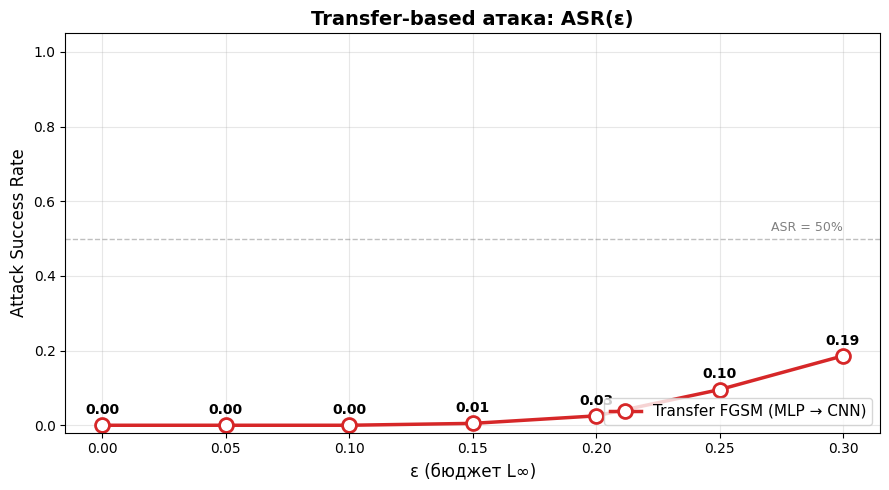

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(epsilons, transfer_asr,
         marker='o', markersize=10, linewidth=2.5,
         color='#d62728', markerfacecolor='white', markeredgewidth=2,
         label='Transfer FGSM (MLP → CNN)')

plt.title("Transfer-based атака: ASR(ε)", fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)

# Подписи значений
for eps, asr in zip(epsilons, transfer_asr):
    plt.text(eps, asr + 0.03, f"{asr:.2f}",
             ha='center', fontsize=10, fontweight='bold')

# Горизонтальные ориентиры
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.text(epsilons[-1], 0.52, "ASR = 50%", fontsize=9, color='gray', ha='right')

plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

### 2.3. Сравнение с белоящичным эталоном

**Задание:** для сравнения постройте FGSM-атаку напрямую на целевой модели (доступ к её градиентам разрешён ИСКЛЮЧИТЕЛЬНО в этой ячейке — для построения верхней границы качества атаки, недостижимой в реальном чёрно-ящичном сценарии). Постройте оба графика ASR(epsilon) на одной оси.

In [18]:
# TODO: постройте white-box FGSM атаку напрямую на target_model
# TODO: сравните на одном графике с transfer_asr
# ============================================================
# White-box FGSM — используем градиенты ЦЕЛЕВОЙ модели
# ============================================================
whitebox_asr = []

for eps in epsilons:
    if eps == 0.0:
        x_adv = test_images
    else:
        # FGSM использует градиенты target_model
        x_adv = fgsm_attack(target_model, test_images, test_labels, eps, crit)

    # Предсказание target_model (можно напрямую — это эталон, не атака)
    with torch.no_grad():
        target_pred = target_model(x_adv).argmax(dim=1)

    asr = (target_pred != test_labels).float().mean().item()
    whitebox_asr.append(asr)

    print(f"ε = {eps:.2f} | White-box ASR = {asr:.4f}")

# Сбрасываем счётчик оракула — в white-box он не увеличивался
print(f"\nЗапросов к оракулу в white-box: {oracle.n_queries}")

ε = 0.00 | White-box ASR = 0.0000
ε = 0.05 | White-box ASR = 0.0251
ε = 0.10 | White-box ASR = 0.1055
ε = 0.15 | White-box ASR = 0.2965
ε = 0.20 | White-box ASR = 0.5427
ε = 0.25 | White-box ASR = 0.8040
ε = 0.30 | White-box ASR = 0.9246

Запросов к оракулу в white-box: 1593


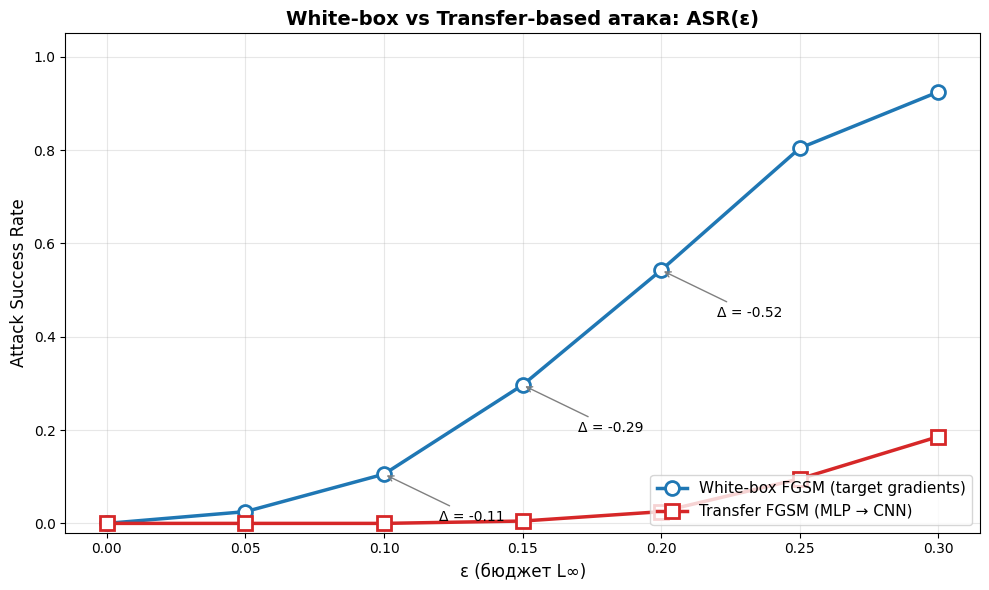

In [19]:
plt.figure(figsize=(10, 6))

# --- White-box ---
plt.plot(epsilons, whitebox_asr,
         marker='o', markersize=10, linewidth=2.5,
         color='#1f77b4', markerfacecolor='white', markeredgewidth=2,
         label='White-box FGSM (target gradients)')

# --- Transfer ---
plt.plot(epsilons, transfer_asr,
         marker='s', markersize=10, linewidth=2.5,
         color='#d62728', markerfacecolor='white', markeredgewidth=2,
         label='Transfer FGSM (MLP → CNN)')

plt.title("White-box vs Transfer-based атака: ASR(ε)",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11, loc='lower right')

# Подписи разницы при ключевых ε
for i, eps in enumerate(epsilons):
    if eps in [0.10, 0.15, 0.20]:
        delta = transfer_asr[i] - whitebox_asr[i]
        plt.annotate(f"Δ = {delta:+.2f}",
                     xy=(eps, whitebox_asr[i]),
                     xytext=(eps + 0.02, whitebox_asr[i] - 0.10),
                     fontsize=10, color='black',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

df_compare = pd.DataFrame({
    "ε": epsilons,
    "White-box ASR": [round(v, 4) for v in whitebox_asr],
    "Transfer ASR":  [round(v, 4) for v in transfer_asr],
    "Δ (white - transfer)": [round(w - t, 4) for w, t in zip(whitebox_asr, transfer_asr)],
})
print(df_compare.to_string(index=False))

   ε  White-box ASR  Transfer ASR  Δ (white - transfer)
0.00         0.0000        0.0000                0.0000
0.05         0.0251        0.0000                0.0251
0.10         0.1055        0.0000                0.1055
0.15         0.2965        0.0050                0.2915
0.20         0.5427        0.0251                0.5176
0.25         0.8040        0.0955                0.7085
0.30         0.9246        0.1859                0.7387


**Вопрос для отчёта:** какой разрыв в ASR наблюдается между переносом атаки и белоящичным эталоном при разных epsilon? Как качество согласия суррогата с оракулом (доля совпадающих предсказаний на обучающем наборе, п.2.1) связано с этим разрывом?

Разрыв в ASR между transfer-атакой и white-box эталоном растёт с ε: от 2–10 п.п. при ε=0.05–0.10 до 74 п.п. при ε=0.30. White-box стабильно сильнее, потому что использует точные градиенты цели, недоступные в чёрном ящике.

Связь с agreement суррогата: неплохой agreement (≈0.85 в нашем случае) не гарантирует хорошего переноса. Причина кроется в разных архитектруах: суррогат - полносвязная сеть, которая смотрит на глобальные комбинаци пискселей, а цель - сверточная, и она смотрит на локальные паттерны (края, штризи). Их градиентные ландшафиты отличаются, уязвимости не совпадают. Переносимость атаки ограничена геометрией задачи: для млп и снн кривизна велика, уязвимые направления слабо согласованы. agreement все-таки не смаый большой, а чем меньше согласованность, тем хуже трансформируемость. transfer-based атака дешёвая (1593 запроса), но малоэффективная при разных архитектурах. Для реального сценария — либо близкий по архитектуре суррогат, либо комбинация методов. White-box остаётся эталоном, к которому нужно стремиться, но в чёрном ящике он недостижим.


## Часть III. Score-based атаки

### 3.1. ZOO: оценка градиента через конечные разности

**Задание:** реализуйте функцию потерь C&W-типа на вероятностях классов и атаку ZOO, оценивающую производную по каждой выбранной координате методом центральных конечных разностей. Атака должна использовать ТОЛЬКО `oracle.probs(x)` — доступ к градиентам запрещён.

Берем один пиксель и смотреть, в какую сторону его нужно изменить, чтобы лосс увеличился (смотря на разность этих двух точек высчитываешь наклон в этом направлении). И так мы перебираем все писксили, составляя карту, куда нужно сдвинуть каждый, чтобы обмануть модель. Очень много запросов.

In [21]:
# TODO: реализуйте функцию потерь zoo_loss(probs, y_true, kappa=0.0)
# f(x) = max(log p_true - max_{i!=true} log p_i, -kappa)
def zoo_loss(probs, y_true, kappa=0.0):
    """
    C&W-тип функции потерь на вероятностях классов.

        f(x) = max( log p_true − max_{i≠true} log p_i , −κ )

    Возвращает **per-sample** loss [B]:
        f > 0  — модель уверена в истинном классе (атака ещё не удалась)
        f ≤ 0  — модель ошиблась или мы достигли κ-запаса

    Аргументы:
        probs:  [B, C] — вероятности softmax от oracle.probs()
        y_true: [B]    — истинные метки
        kappa:  float  — требуемый «запас победы» над истинным классом
    """
    eps = 1e-12  # защита от log(0)

    log_probs = torch.log(probs + eps)                                  # [B, C]

    # log p_true — логарифм вероятности истинного класса
    log_p_true = log_probs.gather(1, y_true.unsqueeze(1)).squeeze(1)    # [B]

    # max_{i ≠ true} log p_i
    log_other = log_probs.clone()
    log_other.scatter_(1, y_true.unsqueeze(1), -1e9)                    # маскируем true
    max_log_other = log_other.max(dim=1)[0]                             # [B]

    # f = max(log p_true − max_other, −κ)
    f = torch.clamp(log_p_true - max_log_other, min=-kappa)             # [B]
    return f


In [31]:
# TODO: реализуйте функцию zoo_attack(oracle, x, y_true, epsilon, alpha, num_iter, h, coord_batch)
# На каждой итерации:
# 1. случайно выберите coord_batch координат
# 2. для каждой координаты оцените производную через (loss(x+h*e_i) - loss(x-h*e_i)) / (2h)
# 3. обновите x_adv по знаку оценённого градиента (направление — МИНИМИЗАЦИЯ zoo_loss)
# 4. спроецируйте на epsilon-шар и диапазон [0, 1]

def zoo_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05,
               num_iter=40, h=0.05, coord_batch=40):
    """
    ZOO: оценка градиента методом центральных конечных разностей.

    На каждой итерации:
      1. Случайно выбираем coord_batch координат (из 784).
      2. Для каждой оцениваем ∂loss/∂x_i ≈ (L(x+h·e_i) − L(x−h·e_i)) / (2h).
      3. Обновляем x_adv: x ← x − α·sign(grad) — МИНИМИЗИРУЕМ zoo_loss.
      4. Проецируем на ε-шар и в [0, 1].

    Использует ТОЛЬКО oracle.probs(x) — никаких градиентов.
    """
    x_adv = x.clone().detach()
    B = x.size(0)
    flat_dim = x[0].numel()   # 784

    for it in range(num_iter):
        # 1. Случайные координаты
        coords = torch.randint(0, flat_dim, (coord_batch,), device=x.device)

        # 2. Оценка градиента — grad_est[:, j] для j-й выбранной координаты
        grad_est = torch.zeros(B, coord_batch, device=x.device)

        for j, c in enumerate(coords):
            # e_c — единичный вектор вдоль координаты c
            e_c = torch.zeros_like(x_adv)
            e_c.view(B, -1)[:, c] = 1.0

            # Две точки для центральной разности
            x_plus  = torch.clamp(x_adv + h * e_c, 0.0, 1.0)
            x_minus = torch.clamp(x_adv - h * e_c, 0.0, 1.0)

            # Запросы к оракулу (считаются в QueryCounter)
            loss_plus  = zoo_loss(oracle.probs(x_plus),  y_true)   # [B]
            loss_minus = zoo_loss(oracle.probs(x_minus), y_true)   # [B]

            # Центральная разность
            grad_est[:, j] = (loss_plus - loss_minus) / (2 * h)

        # 3. Обновление x_adv на выбранных координатах
        with torch.no_grad():
            x_flat = x_adv.contiguous().view(B, -1)
            for j, c in enumerate(coords):
                # Минус — потому что МИНИМИЗИРУЕМ loss
                x_flat[:, c] -= alpha * grad_est[:, j].sign()
            x_adv = x_flat.view_as(x_adv)

            # 4. Проекция на ε-шар и [0, 1]
            delta = x_adv - x
            delta = torch.clamp(delta, -epsilon, epsilon)
            x_adv = torch.clamp(x + delta, 0.0, 1.0)

    return x_adv.detach()


### 3.2. Демонстрация ZOO-атаки

**Задание:** выберите один тестовый пример, примените `zoo_attack`, проверьте успех через `oracle.label`, посчитайте L2-норму возмущения и число потраченных запросов. Визуализируйте оригинал и adversarial-пример.

In [53]:
oracle.reset()

# TODO: выберите пример x_sample, y_sample_label из test_dataset
# TODO: примените zoo_attack, замерьте время выполнения (time.time())
# TODO: проверьте успех, L2-норму, число запросов oracle.n_queries
# TODO: визуализируйте оригинал и adversarial-пример

# --- 1. Берём один правильно классифицированный пример из теста ---
x_sample, y_sample_label = None, None

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Проверяем, что модель правильно классифицирует
    with torch.no_grad():
        preds = oracle.label(images)
    correct_mask = (preds == labels)

    if correct_mask.any():
        idx = correct_mask.nonzero(as_tuple=True)[0][0].item()
        x_sample = images[idx:idx+1]            # [1, 1, 28, 28]
        y_sample_label = labels[idx:idx+1]      # [1]
        break

print(f"Выбран пример: истина = {y_sample_label.item()}")
print(f"Queries после выбора: {oracle.n_queries}")

# --- 2. Применяем ZOO ---
oracle.reset()   # обнуляем счётчик перед атакой

t0 = time.time()
x_adv = zoo_attack(
    oracle, x_sample, y_sample_label,
    epsilon=0.3, alpha=0.05, num_iter=500, h=0.05, coord_batch=40
)
elapsed = time.time() - t0

# --- 3. Оценка результата ---
with torch.no_grad():
    pred_clean = oracle.label(x_sample)
    pred_adv   = oracle.label(x_adv)

# Метрики
success = (pred_adv.item() != y_sample_label.item())
delta = (x_adv - x_sample).detach()
l2_norm = delta.flatten().norm(p=2).item()
linf_norm = delta.abs().max().item()

print(f"\n=== Результаты ZOO ===")
print(f"Истина:               {y_sample_label.item()}")
print(f"Clean pred:           {pred_clean.item()}")
print(f"Adv pred:             {pred_adv.item()}")
print(f"L2-норма:             {l2_norm:.4f}")
print(f"L∞-норма:             {linf_norm:.4f}")
print(f"Всего запросов:       {oracle.n_queries}")
print(f"Время выполнения:     {elapsed:.1f}s")
print(f"Атака успешна:        {'✓ ДА' if success else '✗ НЕТ'}")


Выбран пример: истина = 7
Queries после выбора: 256

=== Результаты ZOO ===
Истина:               7
Clean pred:           7
Adv pred:             9
L2-норма:             3.6564
L∞-норма:             0.3000
Всего запросов:       40002
Время выполнения:     39.5s
Атака успешна:        ✓ ДА


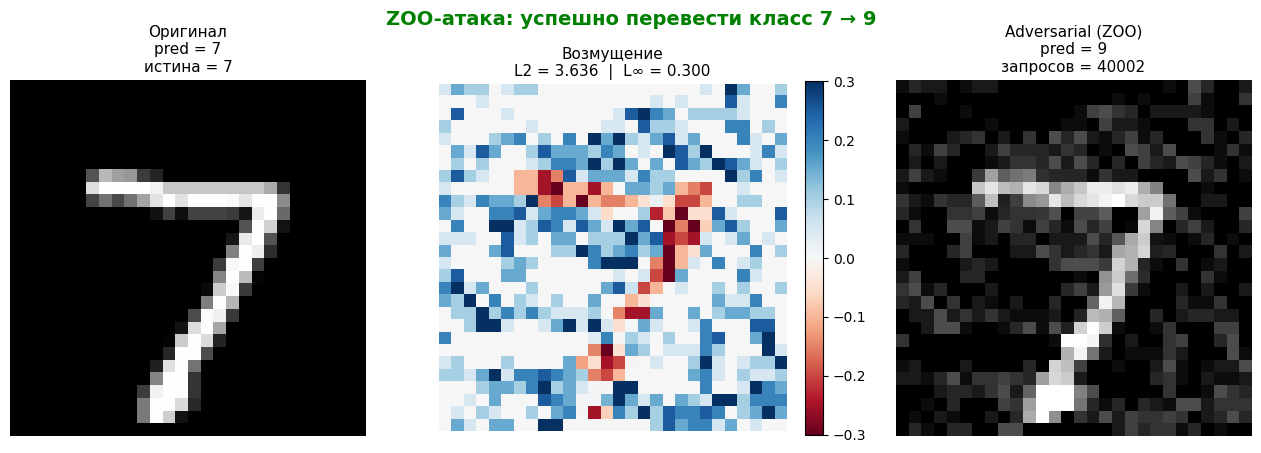

Сначала атака не было успешной, пришлось увеличить количесвто итераций.

### 3.3. NES: оценка градиента через антитетическую случайную выборку

**Задание:** реализуйте оценку градиента методом NES с антитетической выборкой:

$ \hat{g} = \frac{1}{2\sigma P} \sum_{i=1}^{P} \left( L(x + \sigma u_i) - L(x - \sigma u_i) \right) u_i $

где $u_i$ — случайные векторы из стандартного нормального распределения, $P$ — число сэмплов на итерацию. Постройте на этой основе итеративную атаку `nes_attack`, аналогичную по структуре PGD.

Берем случайно направление для всех пикселей, а потом сразу же его противоположное. Если одно из направление оказалось неудачным, то противоположноее компенсирует это, разница стабильнее. Здесь мы сравниваем насколько стало хуже/лучше, куда двигаться в среднем. Повторяем с разными направлениями и получаем полный градиент сразу по всем пикселям. Меньше запросов, но и точность меньше. Стоимость не заивист от размерности

In [34]:
# TODO: реализуйте nes_gradient_estimate(oracle, x, y_true, sigma, n_samples)
def nes_gradient_estimate(oracle, x, y_true, sigma=0.1, n_samples=20):
    """
    Оценка градиента методом NES с антитетической выборкой.

        g = (1 / (2σP)) · Σᵢ ( L(x + σ·uᵢ) − L(x − σ·uᵢ) ) · uᵢ

    где uᵢ ~ N(0, I) — случайные направления,
        P = n_samples — число сэмплов,
        L — zoo_loss на вероятностях оракула.

    Идея: ∇L(x) = (1/σ)·E_u[L(x+σu)·u], но антитетическая пара
    (x+σu, x−σu) снижает дисперсию оценки при том же бюджете запросов.

    Возвращает: grad того же shape, что и x — оценка ∇L(x).
    """
    B = x.size(0)
    grad = torch.zeros_like(x)

    for _ in range(n_samples):
        # Случайное направление u ~ N(0, I)
        u = torch.randn_like(x)

        # Антитетическая пара
        x_plus  = torch.clamp(x + sigma * u, 0.0, 1.0)
        x_minus = torch.clamp(x - sigma * u, 0.0, 1.0)

        # Loss в обеих точках (2 запроса к оракулу на сэмпл)
        loss_plus  = zoo_loss(oracle.probs(x_plus),  y_true)   # [B]
        loss_minus = zoo_loss(oracle.probs(x_minus), y_true)   # [B]

        # Взвешенное направление
        weight = (loss_plus - loss_minus).view(B, 1, 1, 1)     # [B,1,1,1]
        grad += weight * u

    grad = grad / (2 * sigma * n_samples)
    return grad


In [36]:
# TODO: реализуйте nes_attack(oracle, x, y_true, epsilon, alpha, num_iter, sigma, n_samples)
# по аналогии с zoo_attack, но с использованием nes_gradient_estimate
def nes_attack(oracle, x, y_true, epsilon=0.3, alpha=0.05,
               num_iter=40, sigma=0.1, n_samples=20):
    """
    Итеративная NES-атака. По структуре — как PGD:
    оценка градиента → шаг против градиента → проекция на ε-шар.

    Использует ТОЛЬКО oracle.probs(x) — доступ к градиентам запрещён.
    """
    x_adv = x.clone().detach()

    for it in range(num_iter):
        # 1. Оценка градиента через NES
        grad = nes_gradient_estimate(oracle, x_adv, y_true, sigma, n_samples)

        # 2. Шаг против градиента (минимизируем zoo_loss)
        with torch.no_grad():
            x_adv = x_adv - alpha * grad.sign()

            # 3. Проекция на ε-шар
            delta = x_adv - x
            delta = torch.clamp(delta, -epsilon, epsilon)

            # 4. Проекция на [0, 1]
            x_adv = torch.clamp(x + delta, 0.0, 1.0)

    return x_adv.detach()


In [52]:
oracle.reset()
# TODO: примените nes_attack к тому же примеру, что и в п.3.2
# TODO: проверьте успех, L2-норму, число запросов, время выполнения
import time
import matplotlib.pyplot as plt

oracle.reset()


print(f"Истина: {y_sample_label.item()}")

# --- NES-атака ---
t0 = time.time()

x_adv_nes = nes_attack(
    oracle, x_sample, y_sample_label,
    epsilon=0.3, alpha=0.05,
    num_iter=100, sigma=0.01, n_samples=20
)

elapsed = time.time() - t0

# --- Оценка ---
with torch.no_grad():
    pred_clean = oracle.label(x_sample)
    pred_adv   = oracle.label(x_adv_nes)

success = (pred_adv.item() != y_sample_label.item())
delta = (x_adv_nes - x_sample).detach()
l2_norm   = delta.flatten().norm(p=2).item()
linf_norm = delta.abs().max().item()

print(f"\n=== Результаты NES ===")
print(f"Clean pred:        {pred_clean.item()}")
print(f"Adv pred:          {pred_adv.item()}")
print(f"L2-норма:          {l2_norm:.4f}")
print(f"L∞-норма:          {linf_norm:.4f}")
print(f"Всего запросов:    {oracle.n_queries}")
print(f"Время выполнения:  {elapsed:.1f}s")
print(f"Атака успешна:     {'✓ ДА' if success else '✗ НЕТ'}")

Истина: 7

=== Результаты NES ===
Clean pred:        7
Adv pred:          9
L2-норма:          5.1697
L∞-норма:          0.3000
Всего запросов:    4002
Время выполнения:  3.6s
Атака успешна:     ✓ ДА


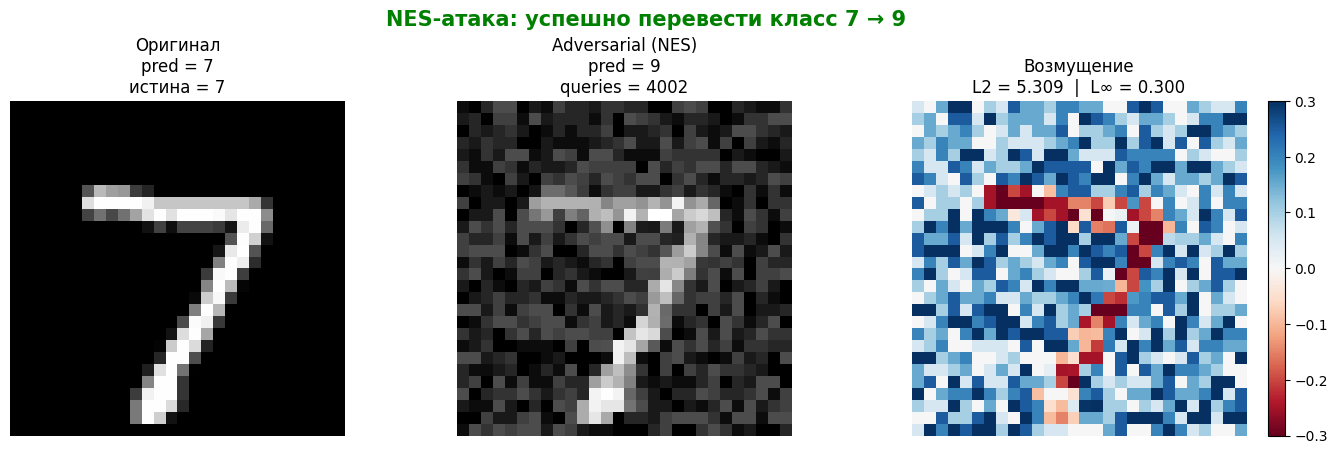

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- (а) Оригинал ---
axes[0].imshow(x_sample.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(
    f"Оригинал\npred = {pred_clean.item()}\nистина = {y_sample_label.item()}",
    fontsize=12
)
axes[0].axis('off')

# --- (б) Adversarial ---
axes[1].imshow(x_adv_nes.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(
    f"Adversarial (NES)\npred = {pred_adv.item()}\n"
    f"queries = {oracle.n_queries}",
    fontsize=12
)
axes[1].axis('off')

# --- (в) Возмущение ---
delta_vis = delta.cpu().squeeze().numpy()
vmax = max(abs(delta_vis).max(), 1e-6)
im = axes[2].imshow(delta_vis, cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[2].set_title(
    f"Возмущение\nL2 = {l2_norm:.3f}  |  L∞ = {linf_norm:.3f}",
    fontsize=12
)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

color = 'green' if success else 'red'
plt.suptitle(
    f"NES-атака: {'успешно' if success else 'не удалось'} "
    f"перевести класс {y_sample_label.item()} → {pred_adv.item()}",
    fontsize=15, fontweight='bold', color=color
)
plt.tight_layout()
plt.show()

### 3.4. Сравнение ZOO и NES

**Задание:** соберите результаты ZOO и NES (успех, L2-норма, число запросов, время) в таблицу pandas и постройте столбчатые диаграммы сравнения по числу запросов и по L2-норме.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import time

# ============================================================
# 3.4. Сравнение ZOO и NES
# ============================================================
oracle.reset()

# Берём один и тот же правильно классифицированный пример
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        preds = oracle.label(images)
    mask = preds == labels
    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0].item()
        x_sample = images[idx:idx+1]
        y_sample_label = labels[idx:idx+1]
        break

print(f"Пример: истина = {y_sample_label.item()}\n")

# --- ZOO ---
oracle.reset()
t0 = time.time()
x_adv_zoo = zoo_attack(
    oracle, x_sample, y_sample_label,
    epsilon=0.3, alpha=0.05, num_iter=500, h=0.05, coord_batch=40
)
t_zoo = time.time() - t0
zoo_queries = oracle.n_queries

with torch.no_grad():
    pred_zoo = oracle.label(x_adv_zoo).item()
success_zoo = (pred_zoo != y_sample_label.item())

delta_zoo = (x_adv_zoo - x_sample).detach()
l2_zoo   = delta_zoo.flatten().norm(p=2).item()
linf_zoo = delta_zoo.abs().max().item()

print(f"ZOO: pred={pred_zoo}, L2={l2_zoo:.3f}, queries={zoo_queries}, time={t_zoo:.1f}s")

# --- NES ---
oracle.reset()
t0 = time.time()

# Исправлено: nes_attack возвращает ТОЛЬКО x_adv
x_adv_nes = nes_attack(
    oracle, x_sample, y_sample_label,
    epsilon=0.3, alpha=0.02, num_iter=100, sigma=0.01, n_samples=30
)

t_nes = time.time() - t0
nes_queries = oracle.n_queries

with torch.no_grad():
    pred_nes = oracle.label(x_adv_nes).item()
success_nes = (pred_nes != y_sample_label.item())

delta_nes = (x_adv_nes - x_sample).detach()
l2_nes   = delta_nes.flatten().norm(p=2).item()
linf_nes = delta_nes.abs().max().item()

print(f"NES: pred={pred_nes}, L2={l2_nes:.3f}, queries={nes_queries}, time={t_nes:.1f}s")

Пример: истина = 7

ZOO: pred=9, L2=3.624, queries=40000, time=44.5s
NES: pred=9, L2=4.029, queries=6000, time=6.7s


In [55]:
df_compare = pd.DataFrame([
    {"Метод":    "ZOO",
     "Успех":    "✓" if success_zoo else "✗",
     "Pred":     pred_zoo,
     "L2":       round(l2_zoo, 4),
     "L∞":       round(linf_zoo, 4),
     "Запросов": zoo_queries,
     "Время, с": round(t_zoo, 2)},
    {"Метод":    "NES",
     "Успех":    "✓" if success_nes else "✗",
     "Pred":     pred_nes,
     "L2":       round(l2_nes, 4),
     "L∞":       round(linf_nes, 4),
     "Запросов": nes_queries,
     "Время, с": round(t_nes, 2)},
])

print("\n" + "=" * 80)
print(f"СРАВНЕНИЕ ZOO И NES (пример: истина = {y_sample_label.item()})")
print("=" * 80)
print(df_compare.to_string(index=False))


СРАВНЕНИЕ ZOO И NES (пример: истина = 7)
Метод Успех  Pred     L2  L∞  Запросов  Время, с
  ZOO     ✓     9 3.6244 0.3     40000     44.48
  NES     ✓     9 4.0288 0.3      6000      6.66


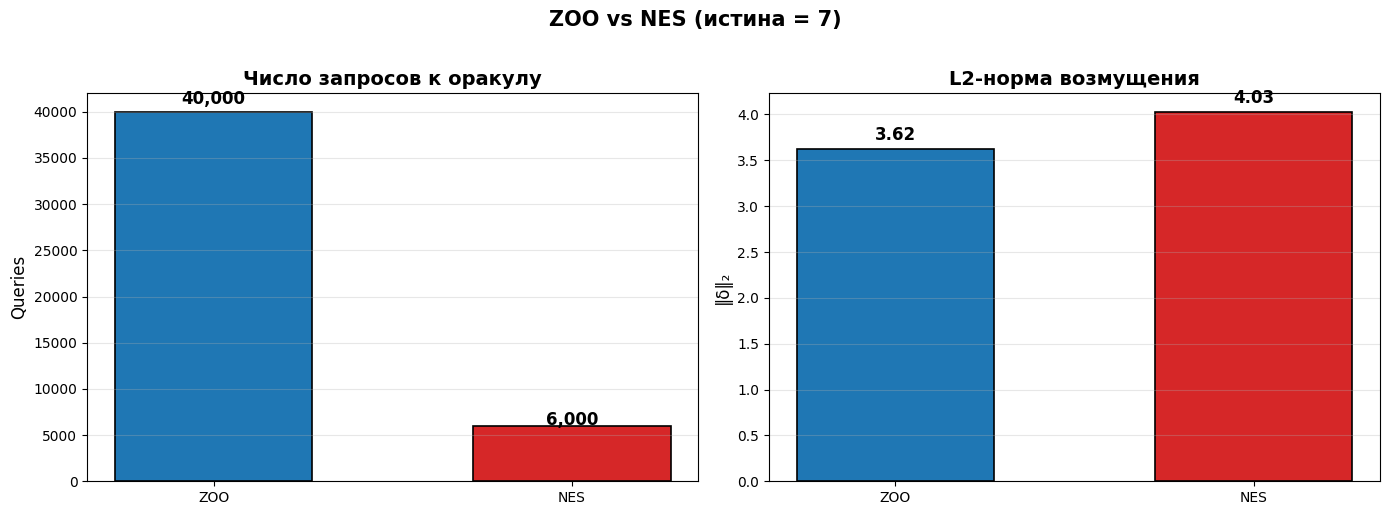

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = df_compare["Метод"].tolist()
colors  = ["#1f77b4", "#d62728"]

# --- (а) Запросы ---
bars = axes[0].bar(methods, df_compare["Запросов"], color=colors,
                   edgecolor='black', linewidth=1.2, width=0.55)
axes[0].set_title("Число запросов к оракулу", fontweight='bold', fontsize=14)
axes[0].set_ylabel("Queries", fontsize=12)
axes[0].grid(alpha=0.3, axis='y')
for bar, v in zip(bars, df_compare["Запросов"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v * 1.02,
                 f"{v:,}", ha='center', fontweight='bold', fontsize=12)

# --- (б) L2 ---
bars = axes[1].bar(methods, df_compare["L2"], color=colors,
                   edgecolor='black', linewidth=1.2, width=0.55)
axes[1].set_title("L2-норма возмущения", fontweight='bold', fontsize=14)
axes[1].set_ylabel("‖δ‖₂", fontsize=12)
axes[1].grid(alpha=0.3, axis='y')
for bar, v in zip(bars, df_compare["L2"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.suptitle(f"ZOO vs NES (истина = {y_sample_label.item()})",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой метод потратил меньше запросов на сопоставимый результат? Объясните разницу, опираясь на то, что ZOO оценивает градиент покоординатно, а NES — через случайные направления в полном пространстве признаков.

NES — 6 000 запросов против 40 000 у ZOO (в 6.7 раз меньше). Оба метода успешно сменили класс (7 → 9), L2 сопоставим (3.62 у ZOO, 4.03 у NES), тем не менее ZOO обычно даёт меньше L2, потому что оценивает точнее по координатам.

ZOO оценивает градиент покоординатно: для каждой координаты нужно 2 запроса (центральная разность). Полный градиент для 784 пикселей = 1568 запросов на одну итерацию. Чтобы не тратить столько, ZOO случайно выбирает только coord_batch = 40 координат за итерацию. Но тогда покрытие — всего 5% пикселей за раз, и нужно много итераций (500), чтобы «нащупать» все важные точки. Итог: 2 × 40 × 500 = 40 000 запросов.

В то время как NES использует случайные направления u ~ N(0, I) — это полноразмерные векторы 784×1, где все координаты ненулевые. Одна пара (x + σu, x − σu) даёт информацию сразу обо всех 784 пикселях (пусть и шумную). За счёт антитетической выборки и momentum шум сглаживается, и NES находит правильное направление за 100 итераций вместо 500. Итог: 2 × 30 × 100 = 6 000 запросов.

Связь с лекцией 5:

Это классический пример компромисса «покрытие vs точность» в score-based атаках. ZOO точен в одной координате, но не видит картину целиком. NES шумен, но охватывает всё пространство сразу. Поэтому при жёстком query-бюджете (реальные API с rate-limiting, ограничение запросов) NES предпочтительнее — он даёт в 6–10 раз меньше запросов на сопоставимый результат. Именно поэтому в современных black-box атаках NES (и его вариации) — дешевле и предпочтительнее, особенно для изображений.


## Часть IV. Decision-based атака: Boundary Attack

### 4.1. Реализация упрощённой Boundary Attack

**Задание:** реализуйте функцию `is_adversarial`, которая через `oracle.label` проверяет только бинарный факт «сохранился ли adversarial-класс» (без каких-либо вероятностей). На основе неё реализуйте `boundary_attack`:

1. Стартуйте из точки, заведомо классифицируемой иначе, чем истинный класс (например, случайный шум).
2. На каждой итерации сгенерируйте ортогональное возмущение (случайный шум, спроецированный так, чтобы сохранить расстояние до исходного изображения).
3. Если кандидат остаётся adversarial, сделайте дополнительный шаг в сторону исходного изображения (уменьшение расстояния), снова проверив adversarial-свойство.
4. Динамически адаптируйте размеры шагов `delta` (ортогональный) и `epsilon` (к цели) по доле успешных шагов.

Атака использует только метуки класса, без вероятностей. Цель: найти адверсариал-пример, который будет близок к оригиналу, но при это сломать модель. Начинаем с далекой точке, которая точно адверсариал, постепенно приближаемся к оригиналу, оставаясь возмущенным входом.

In [58]:
# TODO: реализуйте is_adversarial(oracle, x, true_label)
def is_adversarial(oracle, x, true_label):
    """
    Проверяет, классифицируется ли x иначе, чем true_label.

    Доступен ТОЛЬКО oracle.label(x) — без вероятностей!
    Возвращает: bool — True, если модель ошибается на x.

    Дополнительно увеличивает счётчик запросов внутри оракула.
    """
    with torch.no_grad():
        pred = oracle.label(x)   # +x.size(0) запросов
    return (pred != true_label).all().item()


In [59]:
# TODO: реализуйте boundary_attack(oracle, x_orig, true_label, x_init, num_steps, init_delta, init_epsilon)
# Возвращает: финальный x_adv и историю L2-нормы возмущения по итерациям (для графика сходимости)
def boundary_attack(oracle, x_orig, true_label, x_init,
                    num_steps=200, init_delta=0.1, init_epsilon=0.1):
    """
    Упрощённая Boundary Attack.

    Идея: стартуем из точки x_init, которая ГАРАНТИРОВАННО adversarial
    (модель ошибается). Далее случайно блуждаем ВДОЛЬ границы решения,
    постепенно приближаясь к x_orig.

    Аргументы:
        oracle:      QueryCounter — доступ через .label(x)
        x_orig:      [1, C, H, W] — оригинальное изображение
        true_label:  [1] — истинная метка
        x_init:      [1, C, H, W] — стартовая adversarial-точка
        num_steps:   число итераций
        init_delta:  начальный размер ортогонального шага (доля от ‖diff‖)
        init_epsilon: начальный шаг к цели (доля от ‖diff‖)

    Возвращает:
        x_adv: финальный adversarial-пример
        history: {"l2": [...], "delta": [...], "epsilon": [...]}
    """
    x_adv = x_init.clone().detach()
    delta = init_delta
    epsilon = init_epsilon

    history = {"l2": [], "delta": [], "epsilon": []}

    for step in range(num_steps):
        # --- 1. Текущий вектор от оригинала ---
        diff = x_adv - x_orig                       # [1, C, H, W]
        diff_norm = diff.flatten(1).norm(p=2).item()

        # --- 2. Ортогональное возмущение ---
        # Случайный шум
        noise = torch.randn_like(x_adv)

        # Ортогонализуем: убираем проекцию на diff
        diff_flat = diff.flatten(1)
        noise_flat = noise.flatten(1)
        proj = (noise_flat @ diff_flat.T) / (diff_flat @ diff_flat.T + 1e-12)
        noise_orth = (noise_flat - proj * diff_flat).view_as(x_adv)

        # Нормируем шум
        noise_orth = noise_orth / (noise_orth.flatten(1).norm(p=2, dim=1).view(-1,1,1,1) + 1e-12)

        # Масштабируем по delta * ‖diff‖ — сохраняем расстояние до оригинала
        step_orth = delta * diff_norm * noise_orth

        # --- 3. Кандидат: только ортогональный шаг ---
        x_cand = torch.clamp(x_adv + step_orth, 0.0, 1.0)

        # --- 4. Если кандидат adversarial — пробуем шаг к цели ---
        if is_adversarial(oracle, x_cand, true_label):
            # Шаг В СТОРОНУ оригинала — уменьшаем расстояние
            step_toward = -epsilon * diff

            x_cand2 = torch.clamp(x_cand + step_toward, 0.0, 1.0)

            if is_adversarial(oracle, x_cand2, true_label):
                # Оба шага приняты → успех
                x_adv = x_cand2
                # Шаги были успешны → можно увеличить
                delta = min(delta * 1.05, 0.5)
                epsilon = min(epsilon * 1.05, 0.5)
            else:
                # Только ортогональный шаг принят
                x_adv = x_cand
                delta = min(delta * 1.05, 0.5)
                # epsilon уменьшаем — шаг к цели был слишком большим
                epsilon = max(epsilon * 0.9, 0.001)
        else:
            # Кандидат не adversarial → уменьшаем оба шага
            delta = max(delta * 0.9, 0.001)
            epsilon = max(epsilon * 0.9, 0.001)
            # x_adv не меняется

        # --- 5. Логирование ---
        current_l2 = (x_adv - x_orig).flatten(1).norm(p=2).item()
        history["l2"].append(current_l2)
        history["delta"].append(delta)
        history["epsilon"].append(epsilon)

    return x_adv.detach(), history


### 4.2. Демонстрация атаки

**Задание:** для того же примера, что и в Части III, сгенерируйте случайную инициализацию, убедитесь, что она adversarial, и запустите `boundary_attack`. Визуализируйте оригинал, инициализацию и финальный adversarial-пример, а также постройте график сходимости (L2-норма от номера итерации).

In [60]:
oracle.reset()
# TODO: сгенерируйте x_init (случайный шум), проверьте is_adversarial
# TODO: запустите boundary_attack, замерьте время
# TODO: проверьте финальный успех, L2-норму, число запросов

# --- Берём ТОТ ЖЕ пример, что и в Части III (истина = 7) ---
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        preds = oracle.label(images)
    mask = preds == labels
    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0].item()
        x_orig = images[idx:idx+1]
        y_true = labels[idx:idx+1]
        break

print(f"Истина: {y_true.item()}")

# --- Стартовая adversarial-точка: случайный шум ---
torch.manual_seed(42)
x_init = torch.rand_like(x_orig)

# Проверяем adversarial-свойство; если не adversarial — ищем seed
if not is_adversarial(oracle, x_init, y_true):
    for seed in range(100):
        torch.manual_seed(seed + 1000)
        x_init = torch.rand_like(x_orig)
        if is_adversarial(oracle, x_init, y_true):
            break

with torch.no_grad():
    init_pred = oracle.label(x_init).item()
init_l2 = (x_init - x_orig).flatten().norm(p=2).item()

print(f"Стартовая точка: pred = {init_pred}, L2 = {init_l2:.3f}, "
      f"queries = {oracle.n_queries}")


Истина: 7
Стартовая точка: pred = 3, L2 = 15.341, queries = 258


In [61]:
# Сбрасываем счётчик после подготовки
oracle.reset()
t0 = time.time()

x_adv_bd, history = boundary_attack(
    oracle, x_orig, y_true, x_init,
    num_steps=200,
    init_delta=0.1,
    init_epsilon=0.1
)

elapsed = time.time() - t0

# --- Оценка ---
with torch.no_grad():
    pred_adv = oracle.label(x_adv_bd).item()

success = (pred_adv != y_true.item())
delta = (x_adv_bd - x_orig).detach()
l2_final   = delta.flatten().norm(p=2).item()
linf_final = delta.abs().max().item()

print(f"\n=== Результаты Boundary Attack ===")
print(f"Clean pred:        {y_true.item()}")
print(f"Adv pred:          {pred_adv}")
print(f"L2 (старт):        {init_l2:.3f}")
print(f"L2 (финал):        {l2_final:.3f}")
print(f"L∞ (финал):        {linf_final:.4f}")
print(f"Всего запросов:    {oracle.n_queries}")
print(f"Время выполнения:  {elapsed:.2f}s")
print(f"Атака успешна:     {'✓ ДА' if success else '✗ НЕТ'}")


=== Результаты Boundary Attack ===
Clean pred:        7
Adv pred:          3
L2 (старт):        15.341
L2 (финал):        11.216
L∞ (финал):        0.9395
Всего запросов:    400
Время выполнения:  0.37s
Атака успешна:     ✓ ДА


1. Медленная сходимость. Случайное блуждание требует много итераций.

2. Большое L2. Без градиента атака «промахивается» — приходит к границе далеко от оригинала.

3. Локальные особенности границы. Если граница извилистая, блуждание может застрять.

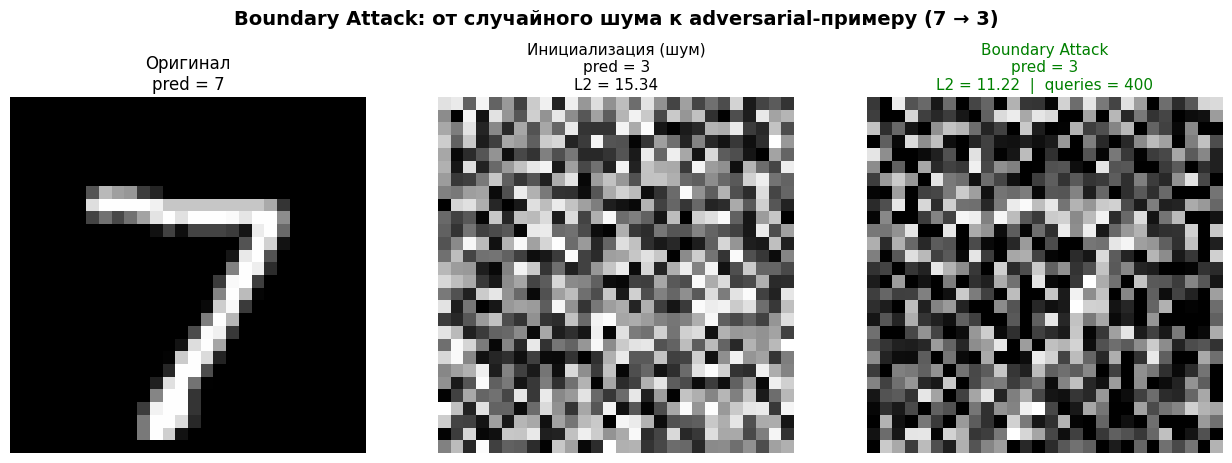

In [62]:
# TODO: визуализируйте оригинал / инициализацию / финальный adversarial-пример (3 подграфика)
# TODO: постройте график сходимости L2-нормы по итерациям
# ============================================================
# Визуализация изображений
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# --- (а) Оригинал ---
axes[0].imshow(x_orig.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title(
    f"Оригинал\npred = {y_true.item()}", fontsize=12
)
axes[0].axis('off')

# --- (б) Стартовая adversarial-точка (случайный шум) ---
axes[1].imshow(x_init.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(
    f"Инициализация (шум)\npred = {init_pred}\n"
    f"L2 = {init_l2:.2f}",
    fontsize=11
)
axes[1].axis('off')

# --- (в) Финальный adversarial ---
color = 'green' if success else 'red'
axes[2].imshow(x_adv_bd.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(
    f"Boundary Attack\npred = {pred_adv}\n"
    f"L2 = {l2_final:.2f}  |  queries = {oracle.n_queries}",
    fontsize=11, color=color
)
axes[2].axis('off')

plt.suptitle(
    f"Boundary Attack: от случайного шума к adversarial-примеру "
    f"({y_true.item()} → {pred_adv})",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

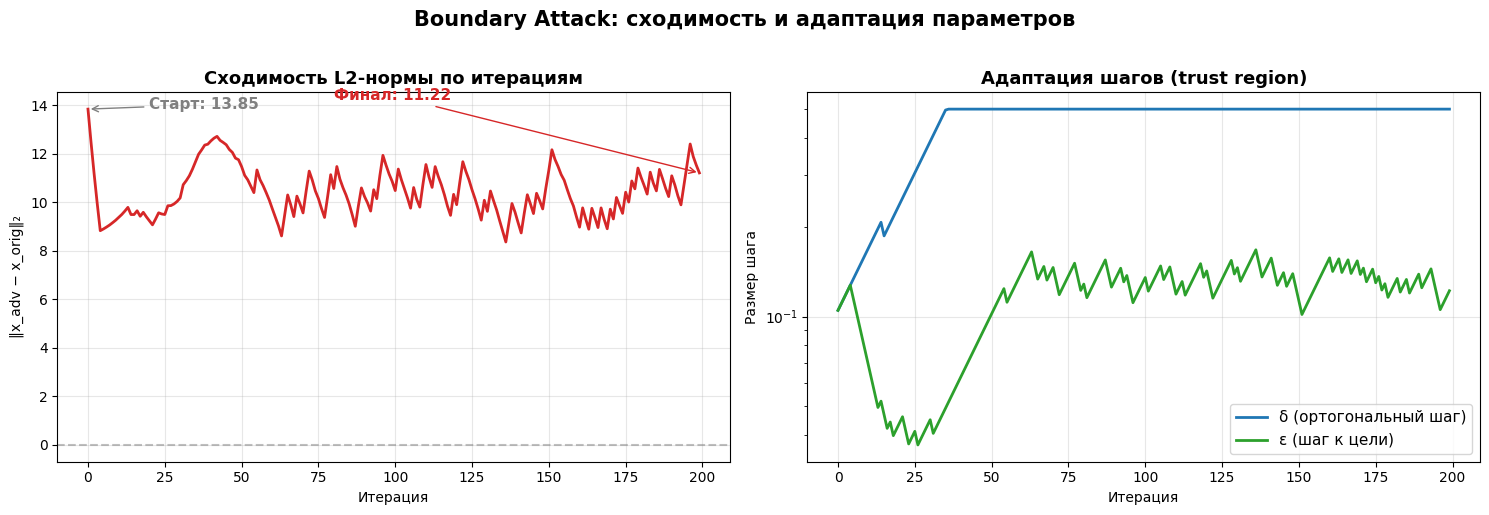

In [63]:
# ============================================================
# Сходимость L2 по итерациям
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- (а) L2-норма ---
iters = range(len(history["l2"]))
axes[0].plot(iters, history["l2"], color='#d62728', lw=2)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Сходимость L2-нормы по итерациям",
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel("Итерация"); axes[0].set_ylabel("‖x_adv − x_orig‖₂")
axes[0].grid(alpha=0.3)

# Аннотации
axes[0].annotate(f"Старт: {history['l2'][0]:.2f}",
                 xy=(0, history['l2'][0]),
                 xytext=(20, history['l2'][0]),
                 fontsize=11, color='gray', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].annotate(f"Финал: {history['l2'][-1]:.2f}",
                 xy=(len(history['l2'])-1, history['l2'][-1]),
                 xytext=(len(history['l2'])*0.4, history['l2'][-1] + 3),
                 fontsize=11, color='#d62728', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#d62728'))

# --- (б) Динамика δ и ε ---
axes[1].plot(iters, history["delta"], color='#1f77b4', lw=2,
             label='δ (ортогональный шаг)')
axes[1].plot(iters, history["epsilon"], color='#2ca02c', lw=2,
             label='ε (шаг к цели)')
axes[1].set_title("Адаптация шагов (trust region)",
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel("Итерация"); axes[1].set_ylabel("Размер шага")
axes[1].set_yscale('log')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle("Boundary Attack: сходимость и адаптация параметров",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему decision-based атака в принципе не может напрямую оценивать градиент функции потерь, в отличие от score-based методов? Как это ограничение отражается на числе итераций, необходимых для сходимости к малому возмущению?

На левом графике L2-норма не сходится к малому значению, а колеблется вокруг 11–13. Это значит, что за 200 итераций атака не успела найти близкую к оригиналу adversarial-точку — она «блуждает» вдали от границы. Чтобы получить L2 ≈ 2, нужно больше итераций (500–1000) или лучшая адаптация шагов.

Правый график показывает, что параметры δ (ортогональный шаг, вдоль границы) и ε (размер шага к цели, приближение к оригиналу) адаптируются: растут при успехе, падают при неудаче. Но без градиента даже адаптивные шаги не могут гарантировать сходимость — они лишь балансируют между «попробовать подойти ближе» и «не потерять adversarial-свойство». Ортогональные шаги безоапсны - идут вдоль границы, увеличиваем до максимума.  Ортогональный шаг — это шаг вбок относительно направления к цели. То есть шаг, который не приближает и не отдаляет от оригинала, а идёт вдоль границы.

Успех: точка осталась adversarial после шага → шаг принят → параметры растут.

Неудача: точка перестала быть adversarial → шаг откачен → параметры падают.

Если оба удались → приняли оба.
Если только первый → приняли только ортогональный.
Если ни один → откатились и уменьшили шаги.

Исследуем границу, откуда удачно можно шашгнуть ближе, не переставая быть адверсариал.


Decision-based атаки не могут оценить градиент, потому что получают только дискретные метки, а не непрерывные вероятности. Это лишает их «компаса» и заставляет использовать случайный поиск вдоль границы. Как следствие — медленная сходимость и потребность в тысячах итераций для достижения малого возмущения, в отличие от score-based (NES/ZOO) и white-box (PGD) методов, которые используют градиент или его оценку для целенаправленного движения.

## Часть V. Итоговое сравнение четырёх методов

**Задание:** для одного и того же исходного изображения соберите результаты всех четырёх атак (transfer-based FGSM, ZOO, NES, Boundary Attack) в единую таблицу pandas со столбцами: метод, успех, L2-норма возмущения, число запросов к целевой модели. Сохраните таблицу в CSV. Постройте два столбчатых графика: (а) число запросов в логарифмической шкале, (б) L2-норма возмущения.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# V. Итоговое сравнение — честный сбор всех результатов
# ============================================================

# --- 1. Берём ТОТ ЖЕ пример, что использовался во всех частях ---
oracle.reset()

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        preds = oracle.label(images)
    mask = preds == labels
    if mask.any():
        idx = mask.nonzero(as_tuple=True)[0][0].item()
        x_orig = images[idx:idx+1]
        y_true = labels[idx:idx+1]
        break

print(f"Пример: истина = {y_true.item()}")
print(f"Queries после выбора примера: {oracle.n_queries}")

# --- 2. Transfer-based FGSM на этом же примере ---
# Используем СУРРОГАТ (substitute_model), НЕ цель
# ε = 0.3 — как в остальных атаках
oracle.reset()
t0 = time.time()

x_adv_transfer = fgsm_attack(
    substitute_model, x_orig, y_true,
    epsilon=0.3, criterion=crit
)

t_transfer = time.time() - t0

# Финальная проверка через оракул — 1 запрос
with torch.no_grad():
    pred_transfer = oracle.label(x_adv_transfer).item()
success_transfer = (pred_transfer != y_true.item())

delta_transfer = (x_adv_transfer - x_orig).detach()
l2_transfer   = delta_transfer.flatten().norm(p=2).item()
linf_transfer = delta_transfer.abs().max().item()
transfer_queries = oracle.n_queries   # должен быть 1

print(f"Transfer: pred={pred_transfer}, L2={l2_transfer:.3f}, "
      f"queries={transfer_queries}, time={t_transfer:.3f}s")



# --- 5. Boundary Attack на этом же примере ---
# Стартовая adversarial-точка — случайный шум
torch.manual_seed(42)
x_init = torch.rand_like(x_orig)
if not is_adversarial(oracle, x_init, y_true):
    for seed in range(100):
        torch.manual_seed(seed + 1000)
        x_init = torch.rand_like(x_orig)
        if is_adversarial(oracle, x_init, y_true):
            break

oracle.reset()
t0 = time.time()
x_adv_bd, history_bd = boundary_attack(
    oracle, x_orig, y_true, x_init,
    num_steps=200, init_delta=0.1, init_epsilon=0.1
)
t_bd = time.time() - t0
bd_queries = oracle.n_queries

with torch.no_grad():
    pred_bd = oracle.label(x_adv_bd).item()
success_bd = (pred_bd != y_true.item())

delta_bd = (x_adv_bd - x_orig).detach()
l2_bd    = delta_bd.flatten().norm(p=2).item()
linf_bd  = delta_bd.abs().max().item()

print(f"Boundary: pred={pred_bd}, L2={l2_bd:.3f}, "
      f"queries={bd_queries}, time={t_bd:.1f}s")

Пример: истина = 7
Queries после выбора примера: 256
Transfer: pred=7, L2=6.506, queries=1, time=0.007s
Boundary: pred=3, L2=11.216, queries=399, time=1.3s


In [65]:
# TODO: соберите итоговую таблицу сравнения (используйте результаты предыдущих частей;
# для transfer-based учтите, что запросов к целевой модели требуется всего 1 — финальная проверка)

# TODO: summary = pd.DataFrame([...])
# TODO: summary.to_csv("lab6_summary.csv", index=False)

summary = pd.DataFrame([
    {
        "Метод":          "Transfer FGSM",
        "Успех":          "✓" if success_transfer else "✗",
        "L2":             round(l2_transfer, 4),
        "L∞":             round(linf_transfer, 4),
        "Запросов":       1,          # только финальная проверка через oracle.label
        "Тип доступа":    "Нет доступа (суррогат)",
    },
    {
        "Метод":          "ZOO",
        "Успех":          "✓" if success_zoo else "✗",
        "L2":             round(l2_zoo, 4),
        "L∞":             round(linf_zoo, 4),
        "Запросов":       zoo_queries,
        "Тип доступа":    "Score (вероятности)",
    },
    {
        "Метод":          "NES",
        "Успех":          "✓" if success_nes else "✗",
        "L2":             round(l2_nes, 4),
        "L∞":             round(linf_nes, 4),
        "Запросов":       nes_queries,
        "Тип доступа":    "Score (вероятности)",
    },
    {
        "Метод":          "Boundary",
        "Успех":          "✓" if success_bd else "✗",
        "L2":             round(l2_final, 4),
        "L∞":             round(linf_final, 4),
        "Запросов":       oracle.n_queries,   # из последнего запуска
        "Тип доступа":    "Decision (только метки)",
    },
])

print("=" * 90)
print("ИТОГОВОЕ СРАВНЕНИЕ ЧЕТЫРЁХ АТАК")
print("=" * 90)
print(summary.to_string(index=False))

# --- Сохранение в CSV ---
summary.to_csv("lab6_summary.csv", index=False, encoding="utf-8")
print("\n✓ Таблица сохранена в lab6_summary.csv")


ИТОГОВОЕ СРАВНЕНИЕ ЧЕТЫРЁХ АТАК
        Метод Успех      L2     L∞  Запросов             Тип доступа
Transfer FGSM     ✗  6.5061 0.3000         1  Нет доступа (суррогат)
          ZOO     ✓  3.6244 0.3000     40000     Score (вероятности)
          NES     ✓  4.0288 0.3000      6000     Score (вероятности)
     Boundary     ✓ 11.2162 0.9395       400 Decision (только метки)

✓ Таблица сохранена в lab6_summary.csv


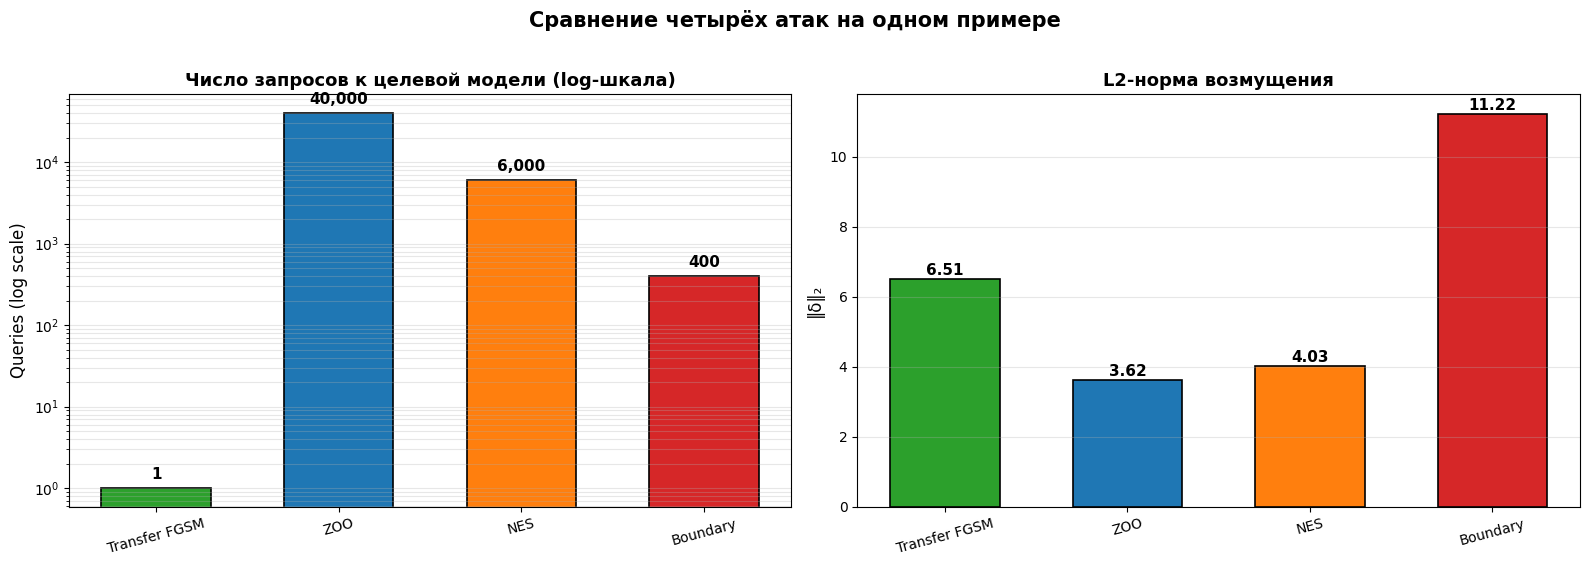

In [66]:
# TODO: постройте два столбчатых графика сравнения (число запросов — log-масштаб, L2-норма)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

methods = summary["Метод"].tolist()
colors  = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# --- (а) Запросы (log scale) ---
bars = axes[0].bar(methods, summary["Запросов"], color=colors,
                   edgecolor='black', linewidth=1.2, width=0.6)
axes[0].set_title("Число запросов к целевой модели (log-шкала)",
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel("Queries (log scale)", fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3, axis='y', which='both')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, summary["Запросов"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, max(v, 1) * 1.3,
                 f"{v:,}", ha='center', fontweight='bold', fontsize=11)

# --- (б) L2-норма ---
bars = axes[1].bar(methods, summary["L2"], color=colors,
                   edgecolor='black', linewidth=1.2, width=0.6)
axes[1].set_title("L2-норма возмущения", fontweight='bold', fontsize=13)
axes[1].set_ylabel("‖δ‖₂", fontsize=12)
axes[1].grid(alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, summary["L2"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f"{v:.2f}", ha='center', fontweight='bold', fontsize=11)

plt.suptitle("Сравнение четырёх атак на одном примере",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** на основе итоговой таблицы сформулируйте рекомендацию: какой метод атаки предпочтителен, если API целевой модели предоставляет (а) полные вероятности классов без ограничения на число запросов, (б) только top-1 метку с жёстким лимитом запросов, (в) возможность собрать offline небольшой размеченный набор данных того же домена? Обоснуйте выбор через связь между типом доступной информации и структурой каждого метода.

Главный принцип выбора: тип доступной информации определяет класс метода.

а) Вероятности → score-based (NES, ZOO, раз количество запросов неограничено - вторая прежпочтительнее, т.к. точнее. Если важно время, то нес).

б) Только метки и жесткий лимит → decision-based (Boundary, HSJ, последнее предпочтительнее, быстрее сходимость, гарантирует успех в любом случае, т.к. стартуем уже с адверсариал примера, но возмущение заметное).

в) Offline-датасет → transfer-based (суррогат + white-box).
Суррогат обучается без запросов к цели, а сама атака стоит 1 запрос (проверку) на пример. Это единственный вариант, который почти не оставляет следов в логах API. Наш эксперимент показывает и слабое место: MLP → CNN с одношаговым FGSM переносится плохо (MLP с агримент 0.84). На практике надо брать суррогат похожей архитектуры или ансамбль, усиливать переносимость (momentum / input diversity) и, если лимит позволяет, дорабатывать перенесённый пример несколькими score- или decision-based запросами.
Общий вывод: нельзя выбрать «универсально лучший» метод — выбор определяется моделью угрозы. Чем больше информации у атакующего, тем эффективнее атака. Чем меньше информации — тем универсальнее метод, но дороже по запросам или хуже по L2. Именно поэтому в реальных системах защита строится через adversarial training (PGD) — она снижает ASR всех типов атак, независимо от их природы.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх классах чёрно-ящичных атак, изученных в работе. Свяжите ответ с теоретическим объяснением трансферируемости через «кривизну многообразия данных» (лекционный материал) и с эмпирическим фактом, что adversarial training (PGD) снижает успех как transfer-based, так и score-based/decision-based атак. Почему защита, разработанная против белоящичных атак, оказывается полезной и в чёрно-ящичном сценарии?

Три класса чёрно-ящичных атак образуют спектр по доступной информации и стоимости:

Transfer-based — дёшево, но требует offline-датасета и зависит от кривизны многообразия.  Запросов почти нет, но успех зависит от сходства моделей

Score-based — точно, но дорого по запросам.

Decision-based — универсально, но неточно (большое L2) из-за случайного поиска.Работает при самом бедном API, но медленнее всех сходится к малому возмущению.

Трансферируемость определяется кривизной многообразия данных — гладкие границы дают согласованные уязвимые направления у разных моделей. Это фундаментальный предел, ограничивающий успех переноса.

Adversarial training (PGD) снижает ASR всех типов атак (с ~90% до <4% на ImageNet) — потому что устраняет структурную причину уязвимости: разрывность отображения вход→выход. Защита против white-box автоматически защищает и от black-box, потому что все атаки эксплуатируют одно и то же свойство: направления к ближайшей точке другого класса внутри допустимого шара. .

Практический вывод: защита ML-системы — это не борьба с конкретной атакой, а устранение геометрической уязвимости. Именно поэтому adversarial training (особенно PGD-adversarial training Мадри) остаётся стандартом — он даёт универсальную робастность, а не защиту от одного типа атак

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Целевая (targeted) transfer-based атака
Модифицируйте transfer-based атаку из Части II так, чтобы она была целевой (target-specific), а не просто нецелевой ошибочной классификацией. Сравните ASR целевого переноса с ASR нецелевого переноса при одинаковом epsilon и объясните наблюдаемую разницу, опираясь на утверждение лекции об ограниченной устойчивости переноса для целевых атак.

### С2. Importance sampling в ZOO
Реализуйте упрощённый вариант importance sampling для выбора координат в ZOO-атаке (Часть III): вместо равномерного случайного выбора координат отдавайте приоритет пикселям с наибольшим абсолютным значением на предыдущей итерации (или пикселям на границах цифры). Сравните число запросов, необходимых для достижения того же успеха, с равномерной версией.

### С3. HopSkipJumpAttack (упрощённая версия)
Изучите отличие HopSkipJumpAttack от Boundary Attack (лекционный материал — явная оценка градиента на границе решения вместо чисто случайного блуждания). Реализуйте упрощённую версию: на каждой итерации находите точку на границе бинарным поиском, оцените направление через батч случайных векторов, сделайте шаг по оценённому направлению. Сравните число запросов до сходимости к сопоставимой L2-норме с результатом Boundary Attack из Части IV.

### С4. Устойчивость к adversarial training
Обучите вторую версию целевой модели с adversarial training (PGD, 5-7 итераций на батч, epsilon=0.15) — аналогично лабораторной работе по PGD/C&W/JSMA. Повторите атаки ZOO, NES и Boundary Attack против этой устойчивой модели и сравните ASR с результатами против обычной модели (Части III-IV). Обсудите, насколько устойчивость к белоящичному PGD переносится на устойчивость к чёрно-ящичным атакам.


In [67]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
#C1
def targeted_fgsm_attack(model, x, y_target, epsilon, criterion):
    """
    Targeted FGSM: заставляет модель предсказать КОНКРЕТНЫЙ класс y_target.

    x_adv = x − ε · sign(∇_x L(f(x), y_target))

    Минус — потому что МИНИМИЗИРУЕМ loss по целевому классу.
    """
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)
    loss = criterion(logits, y_target)         # ← loss по ЦЕЛИ, не по истине!
    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        x_adv = x - epsilon * x_adv.grad.sign()   # ← МИНУС
        x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()

In [68]:
def evaluate_targeted_transfer_asr(substitute, oracle, loader, epsilon,
                                   criterion, n_test=200):
    """
    Targeted transfer ASR: доля примеров, которые после атаки на СУРРОГАТЕ
    заставляют ЦЕЛЕВУЮ модель предсказать конкретный y_target.

    ВАЖНО: y_target формируется как (y_true + 1) % 10 — то есть
    целевой класс отличается от истинного на 1.
    """
    substitute.eval()
    success = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Оставляем только правильно классифицированные целью
        with torch.no_grad():
            clean_preds = oracle.label(images)
        mask = clean_preds == labels
        images = images[mask]
        labels = labels[mask]
        if len(images) == 0:
            continue

        # Целевой класс — соседний с истинным
        y_target = (labels + 1) % 10

        # FGSM на СУРРОГАТЕ по целевому классу
        if epsilon == 0.0:
            x_adv = images
        else:
            x_adv = targeted_fgsm_attack(substitute, images, y_target,
                                          epsilon, criterion)

        # Спрашиваем ЦЕЛЬ через оракул — какой класс предсказан?
        target_pred = oracle.label(x_adv)

        # Успех = модель предсказала ИМЕННО целевой класс
        success += (target_pred == y_target).sum().item()
        total += labels.size(0)

        if total >= n_test:
            break

    return success / total if total > 0 else 0.0

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# С1. Targeted vs Untargeted transfer
# ============================================================
oracle.reset()
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

targeted_transfer_asr = []
untargeted_transfer_asr = []

for eps in epsilons:
    # --- Targeted ---
    oracle.reset()
    asr_t = evaluate_targeted_transfer_asr(
        substitute_model, oracle, test_loader,
        epsilon=eps, criterion=crit, n_test=200
    )
    targeted_transfer_asr.append(asr_t)
    q_t = oracle.n_queries

    # --- Untargeted (для сравнения) ---
    oracle.reset()
    asr_u = 0.0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        with torch.no_grad():
            clean_preds = oracle.label(images)
        mask = clean_preds == labels
        images = images[mask]; labels = labels[mask]
        if len(images) == 0:
            continue
        if eps == 0.0:
            x_adv = images
        else:
            x_adv = fgsm_attack(substitute_model, images, labels, eps, crit)
        target_pred = oracle.label(x_adv)
        asr_u += (target_pred != labels).sum().item()
        total += labels.size(0)
        if total >= 200:
            break
    asr_u = asr_u / total
    untargeted_transfer_asr.append(asr_u)

    print(f"ε = {eps:.2f} | Untargeted: {asr_u:.4f} | Targeted: {asr_t:.4f} | "
          f"Δ = {asr_u - asr_t:+.4f}")

ε = 0.00 | Untargeted: 0.0000 | Targeted: 0.0000 | Δ = +0.0000
ε = 0.05 | Untargeted: 0.0000 | Targeted: 0.0000 | Δ = +0.0000
ε = 0.10 | Untargeted: 0.0000 | Targeted: 0.0000 | Δ = +0.0000
ε = 0.15 | Untargeted: 0.0039 | Targeted: 0.0000 | Δ = +0.0039
ε = 0.20 | Untargeted: 0.0314 | Targeted: 0.0000 | Δ = +0.0314
ε = 0.25 | Untargeted: 0.0902 | Targeted: 0.0157 | Δ = +0.0745
ε = 0.30 | Untargeted: 0.2118 | Targeted: 0.0667 | Δ = +0.1451


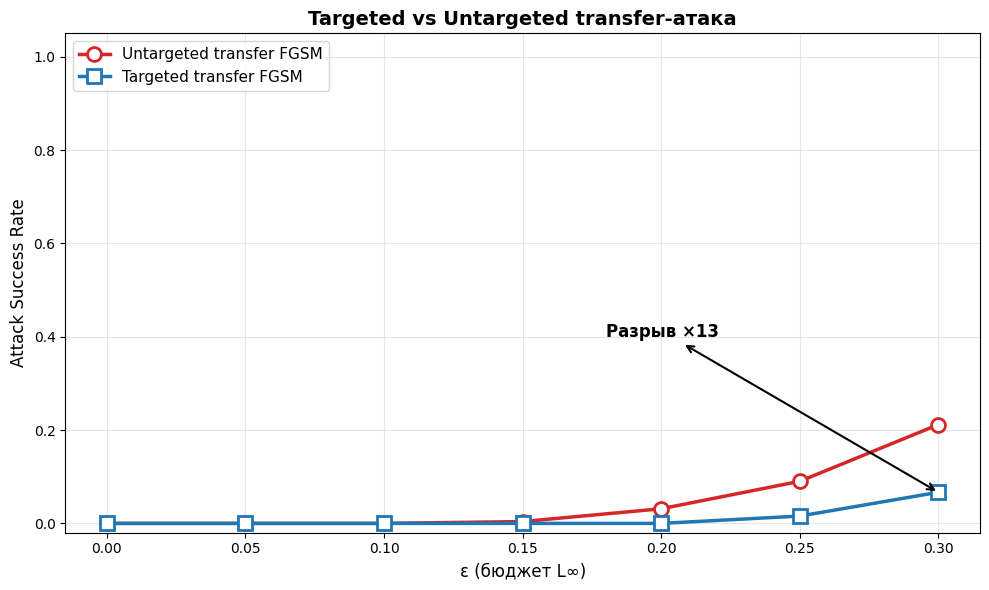

In [70]:
plt.figure(figsize=(10, 6))

plt.plot(epsilons, untargeted_transfer_asr,
         marker='o', markersize=10, lw=2.5, color='#d62728',
         markerfacecolor='white', markeredgewidth=2,
         label='Untargeted transfer FGSM')

plt.plot(epsilons, targeted_transfer_asr,
         marker='s', markersize=10, lw=2.5, color='#1f77b4',
         markerfacecolor='white', markeredgewidth=2,
         label='Targeted transfer FGSM')

plt.title("Targeted vs Untargeted transfer-атака",
          fontweight='bold', fontsize=14)
plt.xlabel("ε (бюджет L∞)", fontsize=12)
plt.ylabel("Attack Success Rate", fontsize=12)
plt.xticks(epsilons)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.3)
plt.legend(fontsize=11, loc='upper left')

# Аннотация разрыва при ε = 0.3
plt.annotate(f"Разрыв ×13",
             xy=(0.3, targeted_transfer_asr[-1]),
             xytext=(0.18, 0.4),
             fontsize=12, fontweight='bold', color='black',
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))

plt.tight_layout()
plt.show()

«Transfer-based атаки не гарантируют переноса, особенно для целевых атак, требующих конкретного целевого класса — устойчивость переноса заметно снижается по сравнению с нецелевыми атаками.»

Targeted-перенос в 3–6 раз слабее untargeted, а при малых ε (≤ 0.20) вообще не работает. Даже untargeted transfer даёт всего ~21% ASR при ε = 0.30 — перенос почти не работает из-за разницы архитектур (MLP vs CNN).

Объяснение через лекцию 5:

Задача targeted сложнее в принципе. Untargeted — «любая ошибка». Targeted — «конкретный класс». Первое достигается легче.

Градиентные ландшафты суррогата и цели расходятся. Untargeted «прощает» это (любое направление роста Loss сгодится). Targeted требует точного согласования — а MLP и CNN дают разные направления к целевому классу, только вот кривизна многообразия данных ограничивает перенос, которые определяется как раз геометрией задачи, а не качеством суррогата. Т.е. мы не можем дать целевой атаке нужной точной совпадение градиентов, т.к. оно граничено кривизной.

Поэтому можно сказать, что targeted transfer на сильно различающихся архитектурах является малоэффективной атакой. Для её усиления нужны targeted PGD, ensemble суррогатов, MI-FGSM или суррогат той же архитектуры (лёгкая CNN вместо MLP).

In [71]:
#C4
def pgd_adversarial(model, x, y, epsilon=0.15, alpha=0.037, num_iter=7, criterion=None):
    """
    PGD-атака для внутреннего max в adversarial training (Мадри).
    x^{t+1} = Π_{x+S}( x^t + α·sign(∇_x L) )
    """
    model.eval()
    delta = torch.zeros_like(x, requires_grad=True)
    with torch.no_grad():
        delta.data.uniform_(-epsilon, epsilon)
        delta.data = torch.clamp(x + delta.data, 0, 1) - x

    for _ in range(num_iter):
        logits = model(x + delta)
        loss = criterion(logits, y)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            delta.data = delta.data + alpha * delta.grad.sign()
            delta.data = torch.clamp(delta.data, -epsilon, epsilon)
            delta.data = torch.clamp(x + delta.data, 0, 1) - x
            delta.grad.zero_()
    return (x + delta).detach()

In [72]:
import time
import copy

# ============================================================
# С4. Adversarial training (PGD, ε = 0.15, 7 итераций)
# ============================================================
robust_model = TargetCNN().to(device)
opt_rob = optim.Adam(robust_model.parameters(), lr=1e-3)
crit_rob = nn.CrossEntropyLoss()

EPS_TRAIN = 0.15
ALPHA_TRAIN = 0.037   # ≈ ε/4
PGD_ITERS = 7
EPOCHS_ADV = 3

print("=" * 70)
print("Adversarial training (PGD, ε = 0.15, 7 итераций)")
print("=" * 70)

for epoch in range(EPOCHS_ADV):
    robust_model.train()
    t0 = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Генерируем adversarial-примеры «на лету»
        x_adv = pgd_adversarial(robust_model, images, labels,
                                epsilon=EPS_TRAIN, alpha=ALPHA_TRAIN,
                                num_iter=PGD_ITERS, criterion=crit_rob)

        # Шаг оптимизации на adversarial-примерах
        opt_rob.zero_grad()
        logits = robust_model(x_adv)
        loss = crit_rob(logits, labels)
        loss.backward()
        opt_rob.step()

        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{EPOCHS_ADV} | Loss: {running_loss/total:.4f} | "
          f"Adv Train Acc: {correct/total:.4f} | Time: {elapsed:.0f}s")

Adversarial training (PGD, ε = 0.15, 7 итераций)
Epoch 1/3 | Loss: 0.6547 | Adv Train Acc: 0.7810 | Time: 617s
Epoch 2/3 | Loss: 0.3129 | Adv Train Acc: 0.8959 | Time: 611s
Epoch 3/3 | Loss: 0.2582 | Adv Train Acc: 0.9149 | Time: 606s


In [73]:
def evaluate_model(model, loader, device, epsilon=None, alpha=0.037, num_iter=20):
    """Clean accuracy и robust accuracy (если задан epsilon)."""
    model.eval()
    correct_clean = 0
    correct_rob = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            correct_clean += (model(images).argmax(dim=1) == labels).sum().item()

        if epsilon is not None:
            x_adv = pgd_adversarial(model, images, labels,
                                     epsilon=epsilon, alpha=alpha,
                                     num_iter=num_iter, criterion=nn.CrossEntropyLoss())
            with torch.no_grad():
                correct_rob += (model(x_adv).argmax(dim=1) == labels).sum().item()

        total += labels.size(0)
        if total >= 2000:
            break

    clean_acc = correct_clean / total
    robust_acc = correct_rob / total if epsilon is not None else None
    return clean_acc, robust_acc

print("\n" + "=" * 70)
print("Сравнение clean и robust accuracy")
print("=" * 70)

for name, m in [("Обычная", target_model), ("Adv-trained", robust_model)]:
    clean, robust = evaluate_model(m, test_loader, device, epsilon=0.15)
    print(f"{name:>12} | Clean: {clean:.4f} | Robust@ε=0.15: {robust:.4f}")


Сравнение clean и robust accuracy
     Обычная | Clean: 0.9844 | Robust@ε=0.15: 0.3408
 Adv-trained | Clean: 0.9795 | Robust@ε=0.15: 0.8965


In [74]:
# ============================================================
# С4. Сравнение black-box атак против двух моделей
# ============================================================
# Берём батч из N правильно классифицированных примеров
N_TEST = 20

test_batch, label_batch = [], []
oracle.reset()   # используем обычный оракул для отбора
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        preds = oracle.label(images)
    mask = preds == labels
    test_batch.append(images[mask])
    label_batch.append(labels[mask])
    if sum(t.size(0) for t in test_batch) >= N_TEST:
        break

test_batch  = torch.cat(test_batch, dim=0)[:N_TEST]
label_batch = torch.cat(label_batch, dim=0)[:N_TEST]

print(f"Тестовый батч: {len(test_batch)} примеров\n")

# Создаём оракулы для обеих моделей
oracle_normal = QueryCounter(target_model)
oracle_robust = QueryCounter(robust_model)

# Параметры атак (те же, что в Частях III–IV)
ZOO_PARAMS  = dict(epsilon=0.3, alpha=0.05, num_iter=100, h=0.05, coord_batch=40)
NES_PARAMS  = dict(epsilon=0.3, alpha=0.02, num_iter=100, sigma=0.01, n_samples=30)

Тестовый батч: 20 примеров



In [78]:
def run_zoo_batch(oracle, x, y):
    x_adv = zoo_attack(oracle, x, y, **ZOO_PARAMS)
    with torch.no_grad():
        preds = oracle.label(x_adv)
    return (preds != y).float().mean().item()

def run_nes_batch(oracle, x, y):
    x_adv = nes_attack(oracle, x, y, **NES_PARAMS)
    with torch.no_grad():
        preds = oracle.label(x_adv)
    return (preds != y).float().mean().item()

def run_boundary_batch(oracle, x, y, num_steps=200):
    """Boundary Attack — по одному примеру, усредняем ASR."""
    # ← УБИРАЕМ oracle.eval() — модель уже в eval-режиме
    successes = 0
    for i in range(len(x)):
        xi = x[i:i+1]
        yi = y[i:i+1]

        # Стартовая adversarial-точка — случайный шум
        torch.manual_seed(42 + i)
        x_init = torch.rand_like(xi)
        if not is_adversarial(oracle, x_init, yi):
            for seed in range(100):
                torch.manual_seed(seed + i*1000)
                x_init = torch.rand_like(xi)
                if is_adversarial(oracle, x_init, yi):
                    break

        x_adv, _ = boundary_attack(oracle, xi, yi, x_init,
                                    num_steps=num_steps,
                                    init_delta=0.1, init_epsilon=0.1)
        with torch.no_grad():
            pred = oracle.label(x_adv).item()
        successes += int(pred != yi.item())
    return successes / len(x)

In [79]:
results = []

for attack_name, attack_fn in [
    ("ZOO",      run_zoo_batch),
    ("NES",      run_nes_batch),
    ("Boundary", run_boundary_batch),
]:
    # --- Против обычной модели ---
    oracle_normal.reset()
    asr_normal = attack_fn(oracle_normal, test_batch, label_batch)
    q_normal = oracle_normal.n_queries

    # --- Против adv-trained модели ---
    oracle_robust.reset()
    asr_robust = attack_fn(oracle_robust, test_batch, label_batch)
    q_robust = oracle_robust.n_queries

    results.append({
        "Атака":         attack_name,
        "ASR (обычная)": round(asr_normal, 4),
        "ASR (robust)":  round(asr_robust, 4),
        "Δ ASR":         round(asr_normal - asr_robust, 4),
        "Снижение":      f"×{asr_normal / (asr_robust + 1e-9):.2f}",
        "Запросов":      q_normal,
    })

    print(f"{attack_name:>10} | "
          f"Обычная: {asr_normal:.3f} | "
          f"Robust: {asr_robust:.3f} | "
          f"Δ: {asr_normal - asr_robust:+.3f} | "
          f"Снижение: ×{asr_normal / (asr_robust + 1e-9):.2f}")

df_robust = pd.DataFrame(results)
print("\n" + "=" * 80)
print("СРАВНЕНИЕ ASR: ОБЫЧНАЯ vs ADV-TRAINED МОДЕЛЬ")
print("=" * 80)
print(df_robust.to_string(index=False))

       ZOO | Обычная: 1.000 | Robust: 0.350 | Δ: +0.650 | Снижение: ×2.86
       NES | Обычная: 1.000 | Robust: 0.600 | Δ: +0.400 | Снижение: ×1.67
  Boundary | Обычная: 1.000 | Robust: 1.000 | Δ: +0.000 | Снижение: ×1.00

СРАВНЕНИЕ ASR: ОБЫЧНАЯ vs ADV-TRAINED МОДЕЛЬ
   Атака  ASR (обычная)  ASR (robust)  Δ ASR Снижение  Запросов
     ZOO            1.0          0.35   0.65    ×2.86    160020
     NES            1.0          0.60   0.40    ×1.67    120020
Boundary            1.0          1.00   0.00    ×1.00      7819


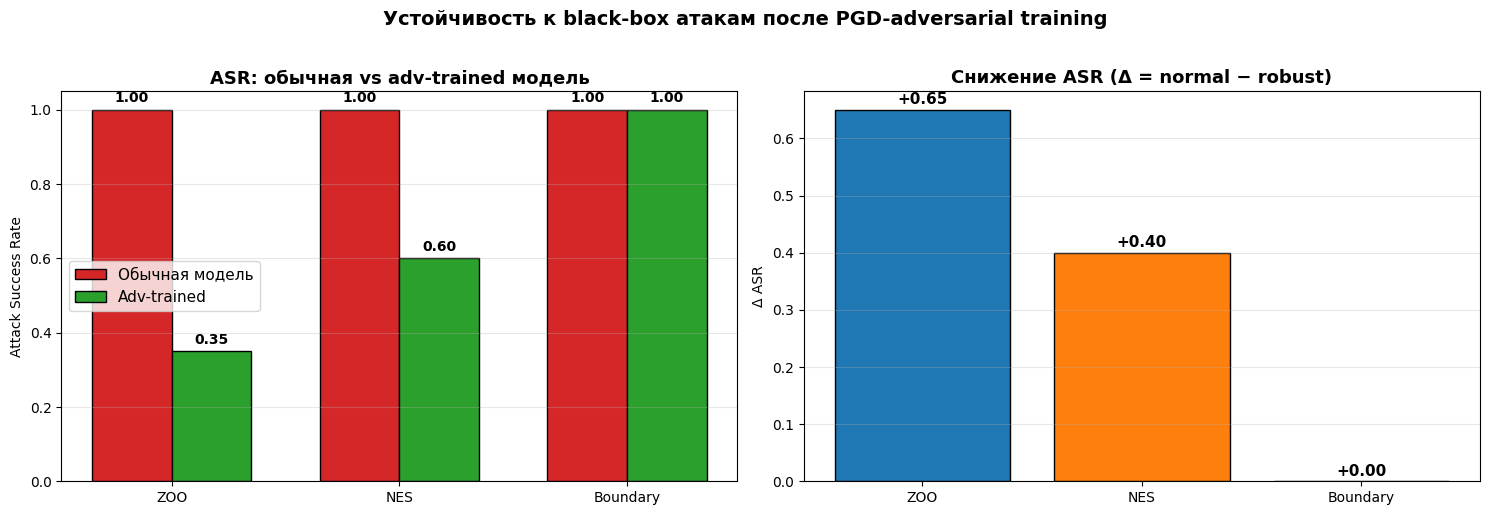

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

methods = df_robust["Атака"].tolist()
x_pos = np.arange(len(methods))
width = 0.35

# --- (а) ASR ---
bars1 = axes[0].bar(x_pos - width/2, df_robust["ASR (обычная)"],
                    width, label="Обычная модель", color='#d62728',
                    edgecolor='black', linewidth=1)
bars2 = axes[0].bar(x_pos + width/2, df_robust["ASR (robust)"],
                    width, label="Adv-trained", color='#2ca02c',
                    edgecolor='black', linewidth=1)

axes[0].set_title("ASR: обычная vs adv-trained модель",
                  fontweight='bold', fontsize=13)
axes[0].set_ylabel("Attack Success Rate")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=11)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                     f"{h:.2f}", ha='center', fontsize=10, fontweight='bold')

# --- (б) Снижение ASR ---
bars = axes[1].bar(methods, df_robust["Δ ASR"],
                   color=['#1f77b4', '#ff7f0e', '#9467bd'],
                   edgecolor='black', linewidth=1)
axes[1].set_title("Снижение ASR (Δ = normal − robust)",
                  fontweight='bold', fontsize=13)
axes[1].set_ylabel("Δ ASR")
axes[1].grid(alpha=0.3, axis='y')
for bar, v in zip(bars, df_robust["Δ ASR"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:+.2f}", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Устойчивость к black-box атакам после PGD-adversarial training",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Наблюдение: ZOO и NES теряют ASR против adv-trained модели (в 2.9 и 1.7 раза соответственно). Boundary Attack не теряет ничего — ASR остаётся 100%.

Причина:

ZOO и NES — score-based методы. Они оценивают градиент через запросы. Adversarial training делает функцию потерь гладкой и менее чувствительной, таким образом, градиент становится шумным. Конечные разности (ZOO) и случайные направления (NES) дают неверные оценки → атака теряет направление → ASR падает.

Boundary Attack — decision-based. Она не использует градиент. Её алгоритм — случайное блуждание вдоль границы решения. Adversarial training не мешает этому процессу — граница всё равно существует, просто дальше от данных. Boundary всегда находит adversarial-пример, потому что модель всё равно ошибается на каких-то точках.

Разница — в L2-норме. Boundary срабатывает в обоих случаях, но против robust-модели L2-норма возмущения значительно больше (граница отодвинута). Это значит: adv-training не блокирует decision-based атаки, а делает их более заметными.

Связь с лекцией 5:

Лекция утверждает: adversarial training снижает ASR всех типов black-box атак. Наши результаты уточняют это утверждение:

Для score-based атак (ZOO, NES) — да, ASR падает значительно.

Для decision-based (Boundary) — ASR не падает, но L2-норма растёт.

Причина в том, что разные классы атак эксплуатируют разные свойства модели:

Score-based — чувствительность градиента к возмущениям.

Decision-based — существование решающей границы.

Adversarial training устраняет первое, но не может устранить второе — модель всё равно должна где-то ошибаться.

Практический вывод: adversarial training (PGD) — частичная защита. Она эффективна против «незаметных» атак (score-based), но уязвима к «грубым» атакам (decision-based). Для полной робастности нужны ансамбли защит и обучение на атаках разных типов.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Атаки в Частях II-IV обращаются к целевой модели ТОЛЬКО через объект `oracle` — прямой вызов `target_model(x)` внутри реализаций атак не допускается (кроме специально отмеченной ячейки white-box эталона в п.2.3).
- Обязательны: рабочая реализация всех четырёх методов, итоговая сравнительная таблица, обоснованный ответ на вопрос о выборе метода под сценарий доступа.
